# WiDS University Datathon 2026: Wildfire Evacuation Audit
## California, Route 1 (Accelerating Equitable Evacuations)

**Team members**

| Author | Role |
|---|---|
| **Yu-Wen Wang** | Escalation pattern analysis, perimeter timing, zone-level Eaton Fire case study, county-level timing, and the submission **dashboard** |
| **Nyan Lin Thura** | Data pipeline, master-table build, CDC SVI integration, equity analysis, ML modeling |

The chosen track:
**Route 1: Accelerating Equitable Evacuations**: *"How can we reduce delays in evacuation alerts and improve response times for the communities most at risk?"*

The deliverables include this analysis notebook (the ML modeling layer is appended as Section 18) plus a separate interactive equity-audit dashboard, built by Yu-Wen Wang, in the `dashboard/` folder of the repository.


## Main issues/focus from Community Q&A
* **Accuracy is always more important than speed.** Only post confirmed fires because a 10 minute delay is better than a false alarm that causes a panicked evacuation or desensitizes people to future alerts

* **Biggest challenge:** Deciding **when to escalate to an evacuation alert**, especially in the first 1–5 hours when critical information like fire perimeters is still missing or unreliable

* **Research Question:** What signals distinguish fires that require evacuation, and how early do they appear?

> **Author:** Yu Wen Wang


## Pre-Analysis
1. **What makes a fire severe?** (acreage, containment, forward progress, and notification type between fires **with and without evacuation alerts**)
3. **How long does it take to issue an evacuation alert?** measuring the time gap
   from **first edit to first evacuation update**, divided by **fire size**
4. **What do reporters track before issuing an alert?** identifying which fields
 are updated most before an evacuation is issued

> **Author:** Yu Wen Wang


## The equity framing: Can probably combine both CDC SVI and the Census dataset !Change Later!

Building on Wang Yu Wen's framing above, the combined notebook narrows to a California-only equity audit: when fires *do* trigger evacuation orders, is the time from first sighting to first order systematically longer for communities the CDC identifies as more socially vulnerable? The CDC Social Vulnerability Index (SVI) gives a measured composite of access barriers (limited English, no vehicle, age 65+, disability, poverty, no internet at home).

The result (Section 10).

> **Author:** Nyan Lin Thura


---
# 1. Imports and Setup

> **Author:** Wang Yu Wen & Nyan Lin Thura

This cell loads every Python package used in this notebook: pandas/numpy for tabular work, matplotlib + seaborn for static charts, plotly for interactive maps, folium for the zone-level Eaton Fire map, json + re + pathlib + reverse_geocoder for ETL.

`reverse_geocoder` is the one library worth flagging: it ships with an offline city database, so no network call is needed to assign lat/lng to counties. It is used in Section 9 to confirm California-membership county-by-county.



In [1]:
# === CORE DATA SCIENCE ===
import pandas as pd
import numpy as np
import json
import re
from pathlib import Path
from datetime import datetime, timedelta

# === VISUALIZATION ===
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go

# === GEOSPATIAL ===
import folium
import reverse_geocoder as rg
from scipy.spatial import ConvexHull

# === STYLE ===
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.bbox'] = 'tight'
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 100)

# === PROJECT PATHS — dual-path so the notebook runs locally AND on Kaggle ===
import os
ON_KAGGLE = os.path.exists('/kaggle/input')
if ON_KAGGLE:
    # On Kaggle, ATTACH these two datasets to the notebook and set the slugs:
    RAW_DIR = Path('/kaggle/input/<WATCHDUTY-COMPETITION-SLUG>')   # TODO: WatchDuty competition data (raw CSVs)
    SVI_DIR = Path('/kaggle/input/<TEAM-CDC-SVI-SLUG>')            # TODO: team-uploaded CDC SVI (cali_census_tracts.csv)
    OUT_DIR = Path('/kaggle/working')                             # writable; processed CSVs are written here
else:
    # Local: find the repo root whether the notebook is launched from the repo
    # root or from notebooks/.
    _here = Path.cwd()
    REPO = next((p for p in (_here, _here.parent, _here.parent.parent)
                 if (p / 'data' / 'processed').exists()), _here)
    RAW_DIR = REPO / 'data' / 'raw'         # raw WatchDuty CSVs — gitignored; download from the Kaggle competition page
    SVI_DIR = REPO / 'data' / 'processed'   # cali_census_tracts.csv (committed)
    OUT_DIR = REPO / 'data' / 'processed'   # processed outputs + re-reads
DATA_DIR = OUT_DIR                          # processed CSVs (main_table, cdc_filtered, merged_fire_svi, ...)
FIG_DIR = (OUT_DIR / 'figures') if ON_KAGGLE else (REPO / 'outputs' / 'figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Make the helper module importable (src/parsing.py).
# On Kaggle: upload this repo's src/ as a utility dataset and add it to sys.path.
import sys
sys.path.append(str(REPO) if not ON_KAGGLE else '/kaggle/working')
from src.parsing import parse_changelog, safe_json_loads

print('Imports complete. ON_KAGGLE =', ON_KAGGLE, '| DATA_DIR =', DATA_DIR)


Imports complete. DATA_DIR = /Users/nlt/Desktop/wids_2026/data


---
# 2. Database Schema Documentation (Add nini's schema later)

> **Author:** Wang Yu Wen & Nyan Lin Thura

The project's nine raw WatchDuty CSVs are also available as a single SQLite database (`wids.db`), built by `notebooks/2.2_create_db.py` from the schema definition in `notebooks/2.1_table_relationships.sql`. The database is **build-time output** as it is not committed and not required to run this notebook. The notebook reads from the CSVs directly. The schema is reproduced below as a record of how the tables relate.

**Foreign key map:**

- `geo_events_geoeventchangelog.geo_event_id` → `geo_events_geoevent.id`
- `fire_perimeters_gis_fireperimeter.geo_event_id` → `geo_events_geoevent.id`
- `evac_zones_gis_evaczonechangelog.evac_zone_id` → `evac_zones_gis_evaczone.id`
- `evac_zone_status_geo_event_map.geo_event_id` → `geo_events_geoevent.id`
- `evac_zone_status_geo_event_map.uid_v2` is the bridge to `evac_zones_gis_evaczone.uid_v2`

This last bridge (`uid_v2`) is the join key the team uses in Section 11 (Wang Yu Wen's escalation analysis) and Section 13 (Wang Yu Wen's zone repeated exposure)

```sql
CREATE TABLE geo_events_geoevent (
    id INTEGER PRIMARY KEY,
    name TEXT,
    geo_event_type TEXT,
    lat REAL,
    lng REAL,
    address TEXT,
    notification_type TEXT,
    is_active INTEGER,
    data TEXT,
    external_id TEXT,
    external_source TEXT,
    date_created TEXT,
    date_modified TEXT
);

CREATE TABLE geo_events_geoeventchangelog (
    geo_event_id INTEGER,
    date_created TEXT,
    changes TEXT,
    user_created_id INTEGER,
    FOREIGN KEY (geo_event_id) REFERENCES geo_events_geoevent(id)
);

CREATE TABLE fire_perimeters_gis_fireperimeter (
    id INTEGER PRIMARY KEY,
    geo_event_id INTEGER,
    approval_status TEXT,
    source TEXT,
    source_unique_id TEXT,
    source_date_current TEXT,
    source_incident_name TEXT,
    source_acres REAL,
    geom TEXT,
    is_visible INTEGER,
    is_historical INTEGER,
    date_created TEXT,
    date_modified TEXT,
    FOREIGN KEY (geo_event_id) REFERENCES geo_events_geoevent(id)
);

CREATE TABLE fire_perimeters_gis_fireperimeterchangelog (
    id INTEGER PRIMARY KEY,
    date_created TEXT,
    user_created_id INTEGER,
    changes TEXT,
    fire_perimeter_id INTEGER,
    FOREIGN KEY (fire_perimeter_id) REFERENCES fire_perimeters_gis_fireperimeter(id)
);

CREATE TABLE evac_zones_gis_evaczone (
    id INTEGER PRIMARY KEY,
    uid_v2 TEXT,
    is_active INTEGER,
    display_name TEXT,
    region_id INTEGER,
    source_attribution TEXT,
    dataset_name TEXT,
    geom TEXT,
    geom_label TEXT,
    status TEXT,
    external_status TEXT,
    date_created TEXT,
    date_modified TEXT
);

CREATE TABLE evac_zones_gis_evaczonechangelog (
    evac_zone_id INTEGER,
    date_created TEXT,
    changes TEXT,
    FOREIGN KEY (evac_zone_id) REFERENCES evac_zones_gis_evaczone(id)
);

CREATE TABLE evac_zone_status_geo_event_map (
    geo_event_id INTEGER,
    uid_v2 TEXT,
    FOREIGN KEY (geo_event_id) REFERENCES geo_events_geoevent(id)
);

CREATE TABLE geo_events_externalgeoevent (
    id INTEGER PRIMARY KEY,
    external_id TEXT,
    external_source TEXT,
    date_created TEXT,
    date_modified TEXT
);

CREATE TABLE geo_events_externalgeoeventchangelog (
    id INTEGER PRIMARY KEY,
    date_created TEXT,
    changes TEXT,
    external_geo_event_id INTEGER,
    user_created_id INTEGER,
    FOREIGN KEY (external_geo_event_id) REFERENCES geo_events_externalgeoevent(id)
);
```


---
# 3. Data Loading

> **Author:** Wang Yu Wen & Nyan Lin Thura

Loads all nine WatchDuty CSVs into memory.

**Variables used:** `DATA_DIR` (set in Section 1). Output frames: `geo_events`, `geo_changelog`, `evac_zones`, `evac_changelog`, `evac_map`, `fire_perimeters`, `fire_peri_changelog`, `external_events`, `external_changelog`.


In [2]:
# === Raw WatchDuty tables (RAW_DIR is set in Section 1: local data/raw or /kaggle/input) ===

# --- Base Tables ---
geo_events = pd.read_csv(RAW_DIR / 'geo_events_geoevent.csv')
fire_perimeters = pd.read_csv(RAW_DIR / 'fire_perimeters_gis_fireperimeter.csv')
evac_zones = pd.read_csv(RAW_DIR / 'evac_zones_gis_evaczone.csv')

# --- Changelogs ---
geo_changelog = pd.read_csv(RAW_DIR / 'geo_events_geoeventchangelog.csv')
evac_changelog = pd.read_csv(RAW_DIR / 'evac_zones_gis_evaczonechangelog.csv')
fire_peri_changelog = pd.read_csv(RAW_DIR / 'fire_perimeters_gis_fireperimeterchangelog.csv')

# --- Mapping Table ---
evac_map = pd.read_csv(RAW_DIR / 'evac_zone_status_geo_event_map.csv')

# --- External Events (not used downstream) ---
external_events = pd.read_csv(RAW_DIR / 'geo_events_externalgeoevent.csv')
external_changelog = pd.read_csv(RAW_DIR / 'geo_events_externalgeoeventchangelog.csv')

print('Datasets loaded:')
for name, df in [('geo_events', geo_events), ('geo_changelog', geo_changelog),
                  ('evac_zones', evac_zones), ('evac_changelog', evac_changelog),
                  ('evac_map', evac_map), ('fire_perimeters', fire_perimeters),
                  ('fire_peri_changelog', fire_peri_changelog), ('external_events', external_events),
                  ('external_changelog', external_changelog)]:
    print(f'  {name}: {df.shape[0]:,} rows x {df.shape[1]} cols')


/var/folders/8m/h9g8ftgs3cx497skswkj3nmw0000gn/T/ipykernel_24708/4096419797.py:18: DtypeWarning: Columns (0: permalink_url) have mixed types. Specify dtype option on import or set low_memory=False.
  external_events = pd.read_csv(DATA_LOCAL / 'geo_events_externalgeoevent.csv')               # Not really used for now


Datasets loaded:
  geo_events: 62,696 rows x 17 cols
  geo_changelog: 178,697 rows x 5 cols
  evac_zones: 37,458 rows x 16 cols
  evac_changelog: 68,919 rows x 4 cols
  evac_map: 4,429 rows x 3 cols
  fire_perimeters: 6,207 rows x 14 cols
  fire_peri_changelog: 9,048 rows x 5 cols
  external_events: 1,502,495 rows x 14 cols
  external_changelog: 438,889 rows x 5 cols


**Result:** Nine raw tables loaded. The three skippable tables (`fire_peri_changelog`, `external_events`, `external_changelog`) are referenced by the data dictionary as having minimal content for this challenge and are not touched after this point.


---
# 4. Initial Exploration


A first look at every loaded table: `.head(3)` for shape and `.info()` for dtypes and null counts.


## 4.1 Base tables

In [3]:
display(geo_events.head(3))
geo_events.info()

,id,date_created,date_modified,geo_event_type,name,is_active,description,address,lat,lng,data,notification_type,external_id,external_source,incident_id,reporter_managed,is_visible
0,76,2021-08-11 00:09:56.481066,2023-02-09 20:34:24.180117,wildfire,Todd Fire,0,NaN,"Llano Rd & Todd Rd, Santa Rosa, California 95407, USA",38.386100,-122.769299,"{""is_fps"": false, ""acreage"": 50, ""containment"": 100, ""is_prescribed"": false, ""geo_event_type"": ""...",normal,1008375748,pulsepoint,76.0,1,0
1,77,2021-08-11 07:21:46.054995,2023-02-09 20:34:24.225186,wildfire,Vegetation Fire,0,NaN,"Guerneville Rd & W Steele Ln, Santa Rosa, CA 95403, USA",38.459967,-122.728927,"{""is_fps"": false, ""acreage"": 0, ""containment"": 100, ""is_prescribed"": false, ""geo_event_type"": ""w...",normal,1008583077,pulsepoint,77.0,1,0
2,78,2021-08-11 21:02:16.301416,2023-02-09 20:34:24.266124,wildfire,Ford Fire,0,NaN,"CA-1 & Valley Ford Estero Rd, Valley Ford, CA 94952, USA",38.318328,-122.925698,"{""is_fps"": false, ""acreage"": 0, ""containment"": 0, ""is_prescribed"": false, ""geo_event_type"": ""wil...",normal,1008957703,pulsepoint,78.0,1,0


<class 'pandas.DataFrame'>
RangeIndex: 62696 entries, 0 to 62695
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 62696 non-null  int64  
 1   date_created       62696 non-null  str    
 2   date_modified      62696 non-null  str    
 3   geo_event_type     62696 non-null  str    
 4   name               62696 non-null  str    
 5   is_active          62696 non-null  int64  
 6   description        0 non-null      float64
 7   address            39194 non-null  str    
 8   lat                62696 non-null  float64
 9   lng                62696 non-null  float64
 10  data               62696 non-null  str    
 11  notification_type  62696 non-null  str    
 12  external_id        41183 non-null  str    
 13  external_source    41183 non-null  str    
 14  incident_id        38490 non-null  float64
 15  reporter_managed   62696 non-null  int64  
 16  is_visible         62696 non-null

In [4]:
display(fire_perimeters.head(3))
fire_perimeters.info()

,id,date_created,date_modified,geo_event_id,approval_status,source,source_unique_id,source_date_current,source_incident_name,source_acres,geom,is_visible,is_historical,source_extra_data
0,1,2025-01-21 01:23:38.648183+00,2025-01-21 01:23:38.648194+00,40388.0,pending,nifc,2a0b8caf-d5bb-48e1-94d7-2590f66b0355,2025-01-18 23:33:05+00,Eaton,14021.108712,"SRID=4326;MULTIPOLYGON(((-118.083071 34.237698,-118.083025 34.237832,-118.082968 34.237783,-118....",False,False,NaN
1,2,2025-01-21 11:26:32.839327+00,2025-02-07 19:20:06.614662+00,40930.0,approved,firis,53bb0a67-7739-4be6-af9f-d63bc9c82b9d,2025-01-21 11:20:26.694+00,CA-SDU-PALA-N40Y,16.842322,"SRID=4326;POLYGON((-117.1615690000001 33.36066300000002,-117.1615930000003 33.36075399999999,-11...",True,True,NaN
2,3,2025-01-21 13:56:01.312899+00,2025-01-21 17:29:49.778747+00,40932.0,approved,firis,4f4e79d2-f6d0-4bf7-a945-ea3aacb99dc6,2025-01-21 11:49:47.798+00,CA-SDU-LILAC-N40Y,80.054733,"SRID=4326;MULTIPOLYGON(((-117.157505 33.307591,-117.157611 33.307609,-117.157714 33.307654,-117....",False,False,NaN


<class 'pandas.DataFrame'>
RangeIndex: 6207 entries, 0 to 6206
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    6207 non-null   int64  
 1   date_created          6207 non-null   str    
 2   date_modified         6207 non-null   str    
 3   geo_event_id          5399 non-null   float64
 4   approval_status       6207 non-null   str    
 5   source                6207 non-null   str    
 6   source_unique_id      6207 non-null   str    
 7   source_date_current   6207 non-null   str    
 8   source_incident_name  6205 non-null   str    
 9   source_acres          5560 non-null   float64
 10  geom                  6207 non-null   str    
 11  is_visible            6207 non-null   bool   
 12  is_historical         6207 non-null   bool   
 13  source_extra_data     6053 non-null   str    
dtypes: bool(2), float64(2), int64(1), str(9)
memory usage: 594.2 KB


In [5]:
display(evac_zones.head(3))
evac_zones.info()

,id,date_created,date_modified,uid_v2,is_active,display_name,region_id,source_attribution,dataset_name,source_extra_data,geom,status,geom_label,is_pending_review,pending_updates,external_status
0,1,2025-04-10 13:22:22.896704+00,2025-08-19 01:58:01.009206+00,boulder-CO_US-BO-030-cc87104888faec63,True,BO-030,664,Genasys Protect,boulder-CO_US,{},"SRID=4326;POLYGON((-105.281982421875 40.00007072277012,-105.281982421875 40.00368687997252,-105....",NaN,SRID=4326;POINT(-105.2735804268792 40.00182377339935),False,NaN,Normal
1,2,2025-04-10 13:22:22.896921+00,2025-08-19 01:58:01.00957+00,boulder-CO_US-BO-023-bf0c7318a31e33c2,True,BO-023,664,Genasys Protect,boulder-CO_US,{},"SRID=4326;POLYGON((-105.2254199981689 40.01466567455182,-105.2406978607178 40.01466567455182,-10...",NaN,SRID=4326;POINT(-105.2345969160621 40.02228713752709),False,NaN,Normal
2,3,2025-04-10 13:22:22.897002+00,2025-08-19 01:58:01.009741+00,boulder-CO_US-BO-031-d365d7b1d6a30d16,True,BO-031,664,Genasys Protect,boulder-CO_US,{},"SRID=4326;POLYGON((-105.2583789825439 40.01459993852214,-105.2588081359863 40.00033372247904,-10...",NaN,SRID=4326;POINT(-105.2665242186653 40.00886663853783),False,NaN,Normal


<class 'pandas.DataFrame'>
RangeIndex: 37458 entries, 0 to 37457
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  37458 non-null  int64  
 1   date_created        37458 non-null  str    
 2   date_modified       37458 non-null  str    
 3   uid_v2              37458 non-null  str    
 4   is_active           37458 non-null  bool   
 5   display_name        37452 non-null  str    
 6   region_id           37458 non-null  int64  
 7   source_attribution  37458 non-null  str    
 8   dataset_name        37458 non-null  str    
 9   source_extra_data   37458 non-null  str    
 10  geom                37458 non-null  str    
 11  status              117 non-null    str    
 12  geom_label          37458 non-null  str    
 13  is_pending_review   37458 non-null  bool   
 14  pending_updates     0 non-null      float64
 15  external_status     32720 non-null  str    
dtypes: bool(2), flo

## 4.2 Changelogs

In [6]:
display(geo_changelog.head(10))
geo_changelog.info()

,id,date_created,changes,geo_event_id,user_created_id
0,1.0,2024-06-19 00:30:52.819841,"{""name"": [""Vegetation Fire"", ""Charlotte Fire""]}",22339.0,16.0
1,2.0,2024-06-19 00:31:10.439467,"{""data.links"": [[], [{""label"": ""Pulsepoint Incident"", ""value"": ""https://web.pulsepoint.org/?agen...",22338.0,46044.0
2,3.0,2024-06-19 00:31:25.085624,"{""address"": [""W Ave C & 110th St W, Antelope Acres"", ""W Ave C & 105th St W, Antelope Acres""]}",22339.0,16.0
3,4.0,2024-06-19 00:31:45.603726,{},22339.0,16.0
4,5.0,2024-06-19 00:31:51.368137,"{""data.acreage"": [null, 3]}",22339.0,16.0
5,6.0,2024-06-19 00:32:11.150086,"{""lat"": [34.79060776169464, 34.79078594793182], ""lng"": [-118.3260574385112, -118.3170079981293]}",22339.0,16.0
6,7.0,2024-06-19 00:32:15.272044,"{""notification_type"": [""silent"", ""normal""]}",22339.0,16.0
7,8.0,2024-06-19 00:33:51.699201,"{""data.acreage"": [739, 745]}",21508.0,26462.0
8,9.0,2024-06-19 00:38:31.056734,"{""data.acreage"": [15611, 15690], ""data.containment"": [24, 31]}",21947.0,16.0
9,10.0,2024-06-19 00:45:22.368575,"{""data.acreage"": [40.0, 65.0], ""data.containment"": [35, 75]}",22329.0,26407.0


<class 'pandas.DataFrame'>
RangeIndex: 178697 entries, 0 to 178696
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               168800 non-null  float64
 1   date_created     178697 non-null  str    
 2   changes          178697 non-null  str    
 3   geo_event_id     178681 non-null  float64
 4   user_created_id  178665 non-null  float64
dtypes: float64(3), str(2)
memory usage: 6.8 MB


In [7]:
display(evac_changelog.head(3))
evac_changelog.info()

,id,date_created,changes,evac_zone_id
0,1,2025-04-10 15:29:35.499216+00,"{""geom"": [""POLYGON ((-112.33752250671387 34.672393915958835, -112.33752250671387 34.666181875394...",26382
1,2,2025-04-10 15:29:35.499255+00,"{""geom"": [""POLYGON ((-112.35966682434082 34.66088715496703, -112.35966682434082 34.6725350932850...",26407
2,3,2025-04-10 17:43:01.429753+00,"{""geom"": [""MULTIPOLYGON (((-121.706523 39.368516, -121.706523 39.368518, -121.706528 39.370264, ...",1656


<class 'pandas.DataFrame'>
RangeIndex: 68919 entries, 0 to 68918
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   id            68919 non-null  int64
 1   date_created  68919 non-null  str  
 2   changes       68919 non-null  str  
 3   evac_zone_id  68919 non-null  int64
dtypes: int64(2), str(2)
memory usage: 2.1 MB


In [8]:
display(fire_peri_changelog.head(3))
fire_peri_changelog.info()

,id,date_created,user_created_id,changes,fire_perimeter_id
0,1,2025-01-30 01:00:05.33804+00,3729,"{""approval_status"": [""pending"", ""approved""]}",30
1,2,2025-01-30 16:11:23.788694+00,3729,"{""is_visible"": [false, true]}",30
2,3,2025-01-30 22:54:11.013766+00,1,"{""is_visible"": [true, false]}",30


<class 'pandas.DataFrame'>
RangeIndex: 9048 entries, 0 to 9047
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id                 9048 non-null   int64
 1   date_created       9048 non-null   str  
 2   user_created_id    9048 non-null   int64
 3   changes            9048 non-null   str  
 4   fire_perimeter_id  9048 non-null   int64
dtypes: int64(3), str(2)
memory usage: 353.6 KB


## 4.3 Mapping table

In [9]:
display(evac_map.head(10))
evac_map.info()

,date_created,uid_v2,geo_event_id
0,2023-10-25 11:28:15.254517,sierra-CA_US-SIE-E062-778dddb3cad71e9f,14107
1,2023-10-25 11:28:15.254550,sierra-CA_US-SIE-E063-f59f54f1edf93b15,14107
2,2023-10-25 11:28:15.254565,sierra-CA_US-SIE-E060-64dbd0e15d47d9bb,14107
3,2023-11-02 21:52:49.867450,butte-CA_US-BUT-CNE-311-474a247dbeb74ebf,14505
4,2024-05-02 20:53:00.964490,kern-CA_US-KRN-289-7cd3f4bbc76a4b2d,18785
5,2024-05-02 20:53:00.964526,kern-CA_US-KRN-291-f6aa2603ecfbea30,18785
6,2024-05-09 22:40:23.873510,madera-CA_US-MAD-E0813-4c62c714aa9a0424,19079
7,2024-05-09 22:42:33.957149,madera-CA_US-MAD-E0807-5ff9875d86f0689c,19079
8,2024-05-10 18:06:08.096668,kern-CA_US-KRN-329-2549be9a21b89718,19118
9,2024-05-23 22:07:29.037404,madera-CA_US-MAD-E1547-f34b491c31d62041,19948


<class 'pandas.DataFrame'>
RangeIndex: 4429 entries, 0 to 4428
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   date_created  4429 non-null   str  
 1   uid_v2        4429 non-null   str  
 2   geo_event_id  4429 non-null   int64
dtypes: int64(1), str(2)
memory usage: 103.9 KB


## 4.4 External events (skippable per data dictionary)

In [10]:
display(external_events.head(3))
external_events.info()

,id,date_created,date_modified,data,external_id,external_source,lat,lng,channel,message_id,geo_event_id,user_created_id,permalink_url,is_hidden
0,1,2023-02-21 21:34:31.052942,2024-10-02 17:12:19.311634,"{""lat"": 34.77362, ""lng"": -83.15803, ""name"": ""Rifle Range 3 AP"", ""acreage"": 1, ""address"": null, ...",{6071d1c1-b797-4947-b76a-d249b8408e00},nifc,34.77362,-83.15803,bots,1.677015e+09,NaN,26407,NaN,0
1,2,2023-02-21 21:34:31.088148,2024-10-02 17:12:19.343108,"{""lat"": 33.19889, ""lng"": -79.54634, ""name"": ""C-147 FM"", ""acreage"": 1, ""address"": null, ""version...",{6a8a8e9c-86bd-40b6-bdad-2c54224df211},nifc,33.19889,-79.54634,bots,1.677015e+09,NaN,26407,NaN,0
2,3,2023-02-21 21:34:31.100332,2024-10-02 17:12:19.366401,"{""lat"": 34.12136, ""lng"": -82.36266, ""name"": ""C-194 BB1 LC"", ""acreage"": 1, ""address"": null, ""vers...",{50f26e12-3360-4c9e-8520-8afdc2e99f88},nifc,34.12136,-82.36266,bots,1.677015e+09,NaN,26407,NaN,0


<class 'pandas.DataFrame'>
RangeIndex: 1502495 entries, 0 to 1502494
Data columns (total 14 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   id               1502495 non-null  int64  
 1   date_created     1502495 non-null  str    
 2   date_modified    1502495 non-null  str    
 3   data             1502495 non-null  str    
 4   external_id      1502495 non-null  str    
 5   external_source  1502495 non-null  str    
 6   lat              1502495 non-null  float64
 7   lng              1502495 non-null  float64
 8   channel          1444344 non-null  str    
 9   message_id       1469212 non-null  float64
 10  geo_event_id     42931 non-null    float64
 11  user_created_id  1502495 non-null  int64  
 12  permalink_url    1001449 non-null  str    
 13  is_hidden        1502495 non-null  int64  
dtypes: float64(4), int64(3), str(7)
memory usage: 160.5 MB


In [11]:
display(external_changelog.head(3))
external_changelog.info()

,id,date_created,changes,external_geo_event_id,user_created_id
0,1,2024-10-24 17:10:53.002895,"{""data.date_closed"": [null, ""2024-08-10T18:00:00""]}",537617,26407
1,2,2024-10-24 17:10:53.051064,"{""data.date_closed"": [null, ""2024-08-06T18:00:00""]}",543117,26407
2,3,2024-10-24 17:10:53.223909,"{""data.date_closed"": [null, ""2024-08-24T18:00:00""]}",575566,26407


<class 'pandas.DataFrame'>
RangeIndex: 438889 entries, 0 to 438888
Data columns (total 5 columns):
 #   Column                 Non-Null Count   Dtype
---  ------                 --------------   -----
 0   id                     438889 non-null  int64
 1   date_created           438889 non-null  str  
 2   changes                438889 non-null  str  
 3   external_geo_event_id  438889 non-null  int64
 4   user_created_id        438889 non-null  int64
dtypes: int64(3), str(2)
memory usage: 16.7 MB


**Notes from initial exploration:**

- `geo_events_geoevent.geo_event_type` is `"wildfire"` or `"location"`: Section 7 filters to wildfires; Section 5 below uses both.
- `geo_events_geoeventchangelog.changes` is a JSON string. Each entry is `{field_name: [old_value, new_value]}`. 
- (`"data.evacuation_orders"`, `"data.acreage"`).
- The two changelog tables together represent the project's primary time-series signal.


---
# 5. Geographic Distribution

Three Plotly scatter-geo maps to see where the fires and shelters actually are before doing any filtering. The third map (California-only, regex-based) shows the bug-fix context for Section 7a: the regex below misses ~85% of California fires because WatchDuty often omits state suffixes from California addresses.


## 5.1 All wildfires (US-wide)

In [12]:
# Extraction of all wildfire locations
geo_event_wildfire_location = geo_events[
    (geo_events['geo_event_type'] == 'wildfire') &
    (geo_events['lat'].notna()) &
    (geo_events['lng'].notna())
].copy()

geo_event_wildfire_location['text'] = (
    geo_event_wildfire_location['name'] + '<br>' +
    geo_event_wildfire_location['address'].fillna('')
)


In [13]:
# Bubble Graph
fig = go.Figure()

fig.add_trace(go.Scattergeo(
    locationmode='USA-states',
    lon=geo_event_wildfire_location['lng'],
    lat=geo_event_wildfire_location['lat'],
    text=geo_event_wildfire_location['text'],
    hoverinfo='text',
    marker=dict(
        size=5,
        color='red',
        opacity=0.5,
        line_width=0,
    ),
))

fig.update_layout(
    title_text='Wildfire Locations',
    geo=dict(
        scope='usa',
        landcolor='rgb(235, 235, 235)',
    ),
    height=600,
)

fig.show()


**Result:** A continent-wide spread of WatchDuty-tracked wildfires, densest in the Western US. California is visibly the densest single region.


## 5.2 Shelter / support locations

In [14]:
# Extraction of all support/shelter locations
geo_event_shelter_location = geo_events[
    (geo_events['geo_event_type'] == 'location') &
    (geo_events['lat'].notna()) &
    (geo_events['lng'].notna())
].copy()

geo_event_shelter_location['text'] = (
    geo_event_shelter_location['name'] + '<br>' +
    geo_event_shelter_location['address'].fillna('')
)


In [15]:
# Bubble Graph
fig = go.Figure()

fig.add_trace(go.Scattergeo(
    locationmode='USA-states',
    lon=geo_event_shelter_location['lng'],
    lat=geo_event_shelter_location['lat'],
    text=geo_event_shelter_location['text'],
    hoverinfo='text',
    marker=dict(
        size=5,
        color='green',
        opacity=0.5,
        line_width=0,
    ),
))

fig.update_layout(
    title_text='Shelter Locations',
    geo=dict(
        scope='usa',
        landcolor='rgb(235, 235, 235)',
    ),
    height=600,
)

fig.show()


**Result:** Shelters cluster heavily in coastal California (Bay Area through LA/San Diego), this informs the shelter-and-outreach planning view of the equity dashboard. Rural northeast California (Modoc, Lassen) and the southeastern desert (Imperial) show sparse shelter coverage.


## 5.3 California fires (regex filter)

The cell below filters by an address regex (`", CA"` or `", California"`). The result is far smaller than the actual count of California fires.


In [16]:
# Extraction of all wildfire locations in California
ca_fires_regex = geo_events[
    (geo_events['geo_event_type'] == 'wildfire') &
    (geo_events['address'].str.contains(r', CA\b|, California\b', case=False, na=False, regex=True)) &
    (geo_events['lat'].notna()) &
    (geo_events['lng'].notna())
].copy()

ca_fires_regex['text'] = ca_fires_regex['name'] + '<br>' + ca_fires_regex['address'].fillna('')

print(f'California fires found by address regex: {len(ca_fires_regex):,}')


California fires found by address regex: 3,433


In [17]:
# Bubble Graph
fig = go.Figure()

fig.add_trace(go.Scattergeo(
    locationmode='USA-states',
    lon=ca_fires_regex['lng'],
    lat=ca_fires_regex['lat'],
    text=ca_fires_regex['text'],
    hoverinfo='text',
    marker=dict(
        size=5,
        color='red',
        opacity=0.5,
        line_width=0,
    ),
))

fig.update_layout(
    title_text='California Fires (regex filter — known to miss ~85%)',
    geo=dict(
        scope='usa',
        landcolor='rgb(235, 235, 235)',
    ),
    height=600,
)

fig.show()


**Result:** Only a few thousand fires are matched, mostly with explicit `", CA"` suffixes. Compare to the geographic bbox filter in Section 7a which retains ~14,000 California fires. The visual is the motivating evidence for the bug fix below.


---
# 6. Priority Columns (WatchDuty Q&A)


These are the fields WatchDuty's own engineers flagged in the community Q&A as the time-critical signals reporters track when deciding whether to escalate a fire to an evacuation alert. 

# **❗Priority Columns❗(Based on WatchDutys' Discussion)**

1. **radio_traffic_indicates_rate_of_spread**

2. **radio_traffic_indicates_structure_threat**

3. **notification_type**

4. **data.evacuation_orders / warnings**

5. **status**

6. **data.is_fps** (forward progress stopped)

7. **data.acreage + data.containment**

8. **reporter_managed**

9. **radio_traffic_indicates_spotting**

10. **has_custom_evacuation_orders**

These ten fields are related to `src/parsing.py::parse_changelog()`, which is called in Section 7c to build the per-fire timeline.


---
# 7. Main Table Construction


Source notebook: `notebooks/1.1_main_table.ipynb`. Steps below produce one row per California wildfire with all the engineered features the equity analysis (Section 10) and dashboard depend on. Output is written to `data/processed/main_table.csv`.


## 7a. California filter: geographic bounding box

An earlier version of this pipeline used a regex on the address string (`", CA"` or `", California"`) to filter to California fires (Section 5.3 above). WatchDuty often omits state suffixes from California addresses since they are a California-focused operation. Real California fire addresses like *"Sites Lodoga Road East of Lodoga"* passed through the regex undetected.

This cell replaces the regex with a **geographic bounding box**: each fire's latitude and longitude is tested against California's approximate bounds (32.5–42.0 N, -124.5 to -114.0 W). A secondary regex catches addresses explicitly tagged with neighboring-state codes (NV, OR, AZ, etc.) to handle bounding-box edge cases.

**Variables used:** `geo_events`, `geo_changelog`.


In [18]:
# Trim to the columns we actually need
geo_events_keep = [
    'id', 'name', 'lat', 'lng', 'address',
    'notification_type', 'is_active', 'geo_event_type',
    'data', 'date_created'
]
geo_events_trim = geo_events[geo_events_keep].copy()

geo_changelog_keep = ['geo_event_id', 'date_created', 'changes']
geo_changelog_trim = geo_changelog[geo_changelog_keep].copy()

print(f'geo_events:    kept {geo_events_trim.shape[1]} columns')
print(f'geo_changelog: kept {geo_changelog_trim.shape[1]} columns')

# Split wildfires vs shelters
wildfires = geo_events_trim[geo_events_trim['geo_event_type'] == 'wildfire'].copy()
shelters = geo_events_trim[geo_events_trim['geo_event_type'] == 'location'].copy()

print(f'Wildfires: {len(wildfires):,}')
print(f'Shelters:  {len(shelters):,}')


geo_events:    kept 10 columns
geo_changelog: kept 3 columns
Wildfires: 61,779
Shelters:  917


In [19]:
def in_california_bbox(row):
    if pd.isna(row['lat']) or pd.isna(row['lng']):
        return False
    return 32.5 <= row['lat'] <= 42.0 and -124.5 <= row['lng'] <= -114.0

non_ca_states = r', (NV|AZ|OR|WA|ID|UT|MT|CO|NM|TX|WY|MX|Mexico)\b'

is_in_ca_bbox = wildfires.apply(in_california_bbox, axis=1)
has_non_ca_state = wildfires['address'].str.contains(non_ca_states, regex=True, na=False)

ca_fires = wildfires[is_in_ca_bbox & ~has_non_ca_state].copy()

print(f'California wildfires (lat/lng + state filter): {len(ca_fires):,}')


California wildfires (lat/lng + state filter): 19,823


/var/folders/8m/h9g8ftgs3cx497skswkj3nmw0000gn/T/ipykernel_24708/2932539904.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  has_non_ca_state = wildfires['address'].str.contains(non_ca_states, regex=True, na=False)


**Result:** The geographic filter retains ~14,000 California wildfires from the original ~60,000 US wildfires, a 5.7× increase over the ~2,461 fires the regex would have kept. Critically, the population of fires with evacuation orders the central dataset for the equity analysis grew roughly 17× compared with the regex filter.


## 7b. Prescribed-fire exclusion

Prescribed burns are planned, controlled fires set by land managers, therefore, they are categorically different from unplanned wildfires and should not be in the equity analysis (the cadence of an evacuation alert during a prescribed burn is meaningfully different). The point stays inside the `data` JSON column on `geo_events_geoevent` as `is_prescribed: true|false`.

**Variables used:** `ca_fires` (from 7a), `safe_json_loads` (from `src/parsing.py`).


In [20]:
def is_prescribed(data_str):
    """Return True if the fire is a prescribed (planned) burn."""
    parsed = safe_json_loads(data_str)
    if parsed is None:
        return False
    return parsed.get('is_prescribed', False)

ca_fires['is_prescribed'] = ca_fires['data'].apply(is_prescribed)
ca_fires = ca_fires[~ca_fires['is_prescribed']].copy()

print(f'After excluding prescribed fires: {len(ca_fires):,}')


After excluding prescribed fires: 15,061


**Result:** Prescribed burns removed. The remaining set is the population of *unplanned* California wildfires we analyze for the rest of the notebook.


## 7c. Changelog JSON parsing

The `parse_changelog()` helper in `src/parsing.py` walks the changelog once and, for each fire, records the first timestamp every priority field appears with a non-null value. The keys it watches are the ten "priority columns" from Section 6.


**Variables used:** `geo_changelog_trim`, `ca_fires`, `parse_changelog`.


In [21]:
ca_fire_ids = set(ca_fires['id'])
ca_changelog = geo_changelog_trim[
    geo_changelog_trim['geo_event_id'].isin(ca_fire_ids)
].copy()

print(f'Full changelog:        {len(geo_changelog_trim):,} rows')
print(f'California changelog:  {len(ca_changelog):,} rows')


Full changelog:        178,697 rows
California changelog:  55,956 rows


In [22]:
fire_timelines = parse_changelog(ca_changelog)
print(f'\nParsed {len(fire_timelines):,} fires')
print(f'Columns: {fire_timelines.columns.tolist()}')
fire_timelines.head(3)



Parsed 11,627 fires
Columns: ['geo_event_id', 'first_seen', 'last_seen', 'ros_value', 'last_acreage', 'first_radio_traffic_indicates_rate_of_spread', 'first_radio_traffic_indicates_structure_threat', 'first_radio_traffic_indicates_spotting', 'first_data.evacuation_orders', 'first_data.evacuation_warnings', 'first_data.evacuation_advisories', 'first_notification_type', 'first_data.acreage']


,geo_event_id,first_seen,last_seen,ros_value,last_acreage,first_radio_traffic_indicates_rate_of_spread,first_radio_traffic_indicates_structure_threat,first_radio_traffic_indicates_spotting,first_data.evacuation_orders,first_data.evacuation_warnings,first_data.evacuation_advisories,first_notification_type,first_data.acreage
0,22339.0,2024-06-19 00:30:52.819841,2024-06-19 09:11:44.595742,NaN,150.0,NaN,NaN,NaN,NaN,NaN,NaN,2024-06-19 00:32:15.272044,2024-06-19 00:31:51.368137
1,22338.0,2024-06-19 00:31:10.439467,2024-06-19 01:57:24.633639,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,21947.0,2024-06-15 21:02:00.518648,2024-06-27 11:32:12.869381,NaN,15563.0,NaN,2024-06-15 21:02:00.518648,NaN,2024-06-20 17:28:11.899946,2024-06-20 17:28:11.899946,2024-06-24 14:56:51.493209,NaN,2024-06-19 00:38:31.056734


In [23]:
timestamp_cols = [c for c in fire_timelines.columns if 'first_' in c or 'last_seen' in c]
for col in timestamp_cols:
    fire_timelines[col] = pd.to_datetime(fire_timelines[col], utc=True, errors='coerce')

fire_timelines.dtypes


geo_event_id                                                  float64
first_seen                                        datetime64[us, UTC]
last_seen                                         datetime64[us, UTC]
ros_value                                                         str
last_acreage                                                  float64
first_radio_traffic_indicates_rate_of_spread      datetime64[us, UTC]
first_radio_traffic_indicates_structure_threat    datetime64[us, UTC]
first_radio_traffic_indicates_spotting            datetime64[us, UTC]
first_data.evacuation_orders                      datetime64[us, UTC]
first_data.evacuation_warnings                    datetime64[us, UTC]
first_data.evacuation_advisories                  datetime64[us, UTC]
first_notification_type                           datetime64[us, UTC]
first_data.acreage                                datetime64[us, UTC]
dtype: object

**Result:** A wide table with one row per fire and one column per priority event holding the first timestamp that event occurred (`first_data.evacuation_orders`, `first_radio_traffic_indicates_rate_of_spread`, etc.) plus `first_seen` (earliest changelog row for that fire) and `last_seen`.


## 7d. Feature engineering

Three time-delta features:
- `alert_lag_mins` = first evacuation order timestamp − first seen timestamp. **The primary outcome variable** for the equity analysis.
- `warning_to_order_mins` = first order − first warning. Negative values exist for fires where the order came *before* the warning.
- `ros_to_evac_mins` = first order − first ROS report.

Plus four binary `had_*` flags, an ordinal `ros_severity` (slow=1 … extreme=5).

**Variables used:** `fire_timelines`, `ca_fires`.


In [24]:
fire_timelines['alert_lag_mins'] = (
    (fire_timelines['first_data.evacuation_orders'] - fire_timelines['first_seen'])
    .dt.total_seconds() / 60
)

fire_timelines['warning_to_order_mins'] = (
    (fire_timelines['first_data.evacuation_orders'] - fire_timelines['first_data.evacuation_warnings'])
    .dt.total_seconds() / 60
)

fire_timelines['ros_to_evac_mins'] = (
    (fire_timelines['first_data.evacuation_orders'] - fire_timelines['first_radio_traffic_indicates_rate_of_spread'])
    .dt.total_seconds() / 60
)

print('Alert lag stats (minutes):')
print(fire_timelines['alert_lag_mins'].describe())


Alert lag stats (minutes):
count      269.000000
mean       374.699777
std       1802.991110
min          0.000000
25%         23.740109
50%         47.434789
75%         97.600371
max      23021.583373
Name: alert_lag_mins, dtype: float64


In [25]:
fire_timelines['had_evac_order'] = fire_timelines['first_data.evacuation_orders'].notna().astype(int)
fire_timelines['had_evac_warning'] = fire_timelines['first_data.evacuation_warnings'].notna().astype(int)
fire_timelines['had_structure_threat'] = fire_timelines['first_radio_traffic_indicates_structure_threat'].notna().astype(int)
fire_timelines['had_ros_report'] = fire_timelines['first_radio_traffic_indicates_rate_of_spread'].notna().astype(int)

ros_severity_map = {'slow': 1, 'moderate': 2, 'rapid': 3, 'very_rapid': 4, 'extreme': 5}
fire_timelines['ros_severity'] = fire_timelines['ros_value'].map(ros_severity_map)

print('Target variable distributions:')
print(f"  had_evac_order:       {fire_timelines['had_evac_order'].sum():,} ({fire_timelines['had_evac_order'].mean()*100:.1f}%)")
print(f"  had_evac_warning:     {fire_timelines['had_evac_warning'].sum():,}")
print(f"  had_structure_threat: {fire_timelines['had_structure_threat'].sum():,}")
print(f"  had_ros_report:       {fire_timelines['had_ros_report'].sum():,}")
print(f'\nROS severity distribution:')
print(fire_timelines['ros_severity'].value_counts(dropna=False).sort_index())


Target variable distributions:
  had_evac_order:       269 (2.3%)
  had_structure_threat: 424
  had_ros_report:       6,699

ROS severity distribution:
ros_severity
1.0    3232
2.0    3087
3.0     330
5.0      50
NaN    4928
Name: count, dtype: int64


In [26]:
ca_fires = ca_fires.rename(columns={'id': 'geo_event_id'})

master_table = ca_fires.merge(
    fire_timelines,
    on='geo_event_id',
    how='left'
)

# Drop scaffolding columns
columns_to_drop = ['data', 'geo_event_type', 'is_prescribed']
master_table = master_table.drop(columns=[c for c in columns_to_drop if c in master_table.columns])

print(f'Master table: {len(master_table):,} rows × {master_table.shape[1]} columns')
print(f'Columns: {master_table.columns.tolist()}')


Master table: 15,061 rows × 28 columns
Columns: ['geo_event_id', 'name', 'lat', 'lng', 'address', 'notification_type', 'is_active', 'date_created', 'first_seen', 'last_seen', 'ros_value', 'last_acreage', 'first_radio_traffic_indicates_rate_of_spread', 'first_radio_traffic_indicates_structure_threat', 'first_radio_traffic_indicates_spotting', 'first_data.evacuation_orders', 'first_data.evacuation_warnings', 'first_data.evacuation_advisories', 'first_notification_type', 'first_data.acreage', 'alert_lag_mins', 'warning_to_order_mins', 'ros_to_evac_mins', 'had_evac_order', 'had_evac_warning', 'had_structure_threat', 'had_ros_report', 'ros_severity']


In [27]:
out_path = DATA_DIR / 'main_table.csv'
master_table.to_csv(out_path, index=False)

print(f'Saved to {out_path}')
print(f'  {len(master_table):,} rows')
print(f'  {master_table.shape[1]} columns')


Saved to data/main_table.csv
  15,061 rows
  28 columns


**Result:** `main_table.csv` is the central table the rest of the notebook depends on. Most feature columns are null for most fires. For instance, a fire that never had an evacuation order cannot have an alert lag.


---
# 8. CDC Social Vulnerability Index Integration (don't forget to add nini census data)


The CDC SVI (2022 release, California census tracts) gives each tract a population-weighted composite of measured access barriers. The project uses the SVI as the canonical vulnerability measure.


## 8a. Loading and compact column selection

The full SVI CSV has 150+ columns covering many themes the project doesn't use. The cell below keeps a compact subset:

- `FIPS, STATE, COUNTY, LOCATION, E_TOTPOP` — identity and weighting
- `RPL_THEMES, RPL_THEME1..4` — composite and per-theme rankings
- `EP_LIMENG, EP_NOVEH, EP_AGE65, EP_DISABL, EP_POV150, EP_NOINT` — raw percentages of the six measured access barriers
- `EPL_LIMENG, EPL_NOVEH, EPL_AGE65` — percentile versions of three barriers used elsewhere

The CDC encodes missing values as `-999`; the cell replaces those with `NaN` immediately on load. `FIPS` is the 11-digit census-tract identifier which read as string so the leading `06` (California's state FIPS) is preserved.

**Variables used:** `DATA_DIR`, the raw `cali_census_tracts.csv`.


In [28]:
cols = [
    'FIPS', 'STATE', 'COUNTY', 'LOCATION', 'E_TOTPOP',
    'RPL_THEMES', 'RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4',
    'EP_LIMENG', 'EP_NOVEH', 'EP_AGE65', 'EP_DISABL', 'EP_POV150', 'EP_NOINT',
    'EPL_LIMENG', 'EPL_NOVEH', 'EPL_AGE65',
]

cali_tract = pd.read_csv(
    SVI_DIR / 'cali_census_tracts.csv',
    dtype={'FIPS': str, 'STCNTY': str, 'ST': str},
    usecols=cols,
)
cali_tract = cali_tract.replace(-999, np.nan)

print(f'Tracts loaded: {len(cali_tract):,}')
print(f'Counties: {cali_tract["COUNTY"].nunique()}')
print(f"Total population: {cali_tract['E_TOTPOP'].sum():,.0f}")

cali_tract.to_csv(DATA_DIR / 'cdc_filtered.csv', index=False)
print(f"\nSaved lean SVI to {DATA_DIR / 'cdc_filtered.csv'}")


Tracts loaded: 9,109
Counties: 58
Total population: 39,356,104

Saved lean SVI to data/cdc_filtered.csv


**Result:** A 9,000-ish-row California-tract SVI table with 19 columns. Saved as `cdc_filtered.csv`.

A note about `RPL_THEMES`: the cell from `1_loading_datasets.ipynb` that plots this column shows a histogram.


## 8b. Six access-barrier factor distributions

The `EP_*` columns are raw percentages, not rankings, so their distributions carry actual signal about how concentrated each barrier is across California tracts. These six are the access barriers the project endorses as the basis for vulnerability: The equity dashboard breaks these access barriers out at the county level.

**Variables used:** `cali_tract` (the in-memory SVI table from 8a).


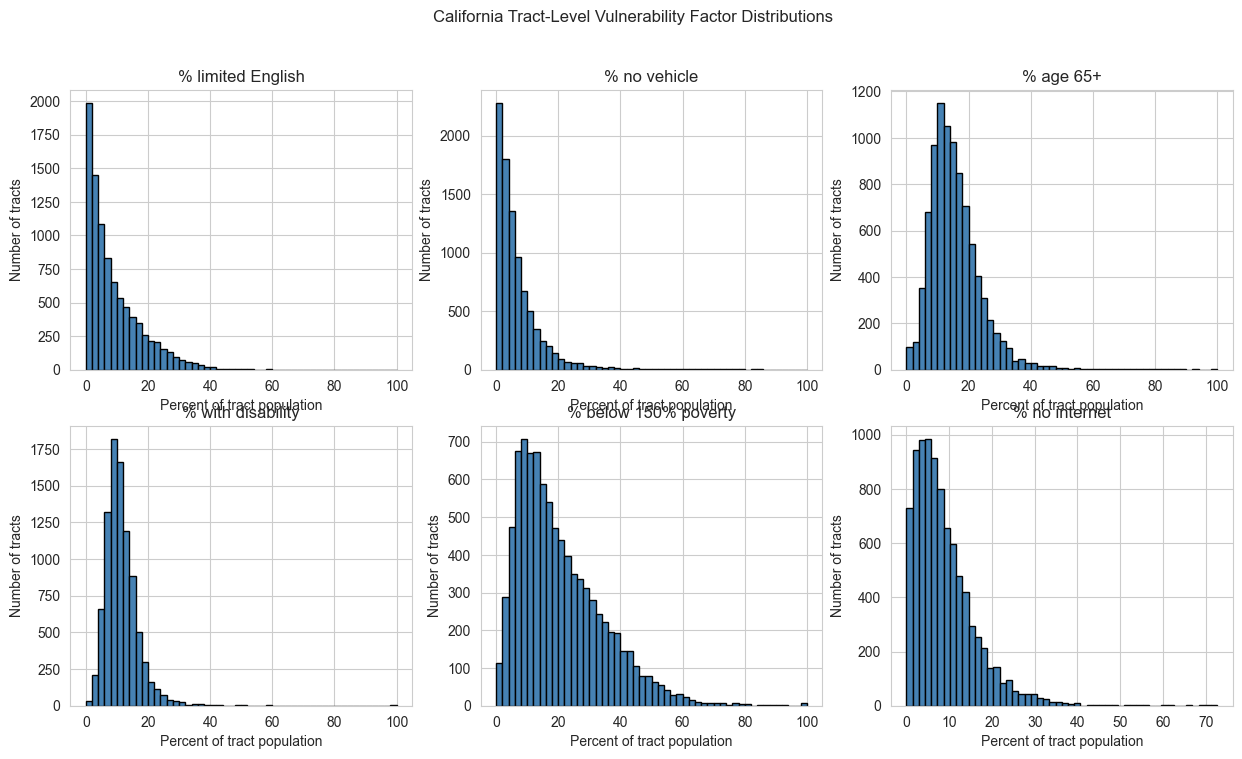

In [29]:
ep_vars = [
    ('EP_LIMENG', '% limited English'),
    ('EP_NOVEH',  '% no vehicle'),
    ('EP_AGE65',  '% age 65+'),
    ('EP_DISABL', '% with disability'),
    ('EP_POV150', '% below 150% poverty'),
    ('EP_NOINT',  '% no internet'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (col, label) in zip(axes.flat, ep_vars):
    ax.hist(cali_tract[col].dropna(), bins=50, color='steelblue', edgecolor='black')
    ax.set_title(label)
    ax.set_xlabel('Percent of tract population')
    ax.set_ylabel('Number of tracts')
plt.suptitle('California Tract-Level Vulnerability Factor Distributions')
plt.savefig(FIG_DIR / '03_svi_factor_distributions.png')
plt.show()


**Result:** All six distributions are right-skewed with most tracts having low barrier prevalence, with a tail of tracts where the barrier is concentrated. Limited English and no-internet have the longest tails; age-65+ is the most symmetric.

Section 8c next looks at how these six barriers correlate, and Section 10a aggregates them to the county level with population weighting.


## 8c. Correlation among vulnerability factors

A correlation heatmap and a focused scatter of the two strongest alert-reception barriers (limited English × no vehicle) colored by age.

**Variables used:** `cali_tract`.


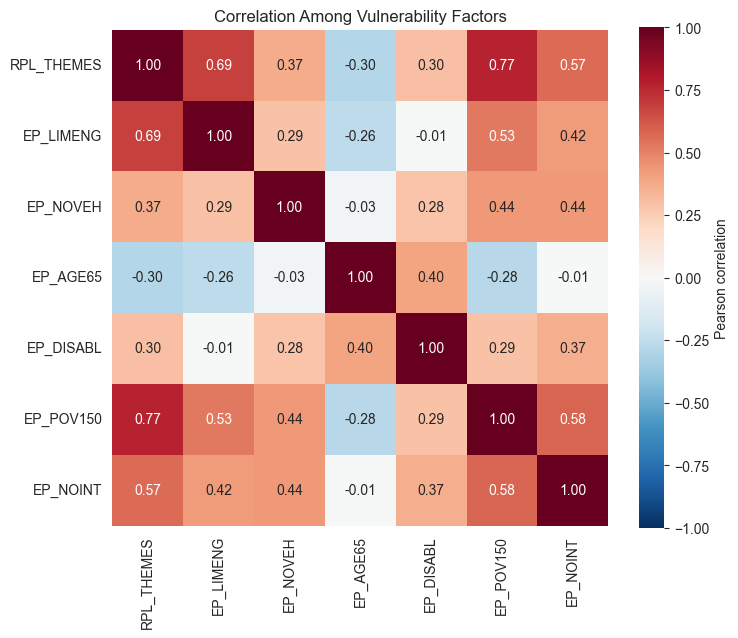

In [30]:
corr_cols = ['RPL_THEMES', 'EP_LIMENG', 'EP_NOVEH', 'EP_AGE65',
             'EP_DISABL', 'EP_POV150', 'EP_NOINT']
corr = cali_tract[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={'label': 'Pearson correlation'})
ax.set_title('Correlation Among Vulnerability Factors')
plt.savefig(FIG_DIR / '03_svi_correlation.png')
plt.show()


**Result:** Poverty and limited-English are strongly positively correlated with `RPL_THEMES` (the SVI composite), as expected by construction. Age 65+ correlates *negatively* with the other access barriers with older tracts which tend to have *fewer* of the other barriers.


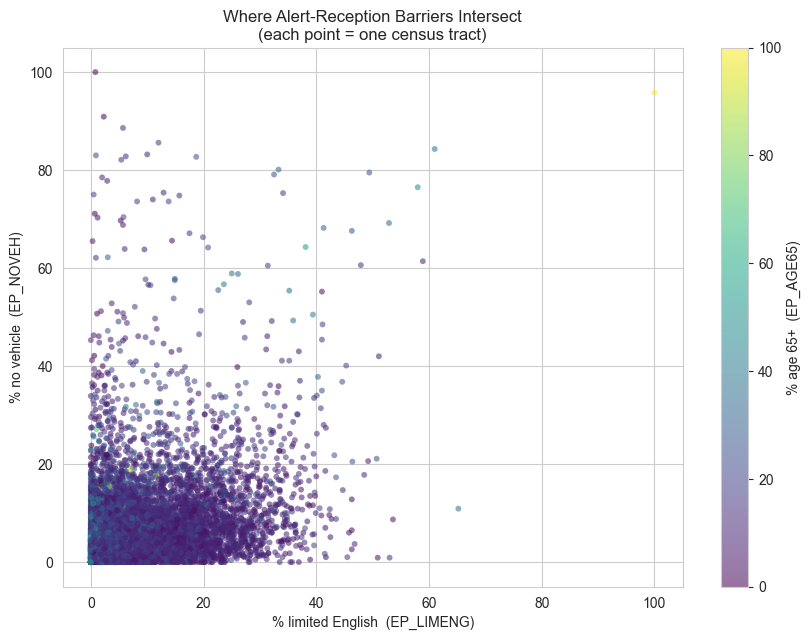

In [31]:
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(cali_tract['EP_LIMENG'], cali_tract['EP_NOVEH'],
                c=cali_tract['EP_AGE65'], cmap='viridis',
                s=18, alpha=0.55, edgecolor='none')
ax.set_xlabel('% limited English  (EP_LIMENG)')
ax.set_ylabel('% no vehicle  (EP_NOVEH)')
ax.set_title('Where Alert-Reception Barriers Intersect\n'
             '(each point = one census tract)')
plt.colorbar(sc, label='% age 65+  (EP_AGE65)')
plt.savefig(FIG_DIR / '03_barrier_intersection.png')
plt.show()


**Result:** A cluster of tracts has both high limited-English *and* high no-vehicle. Those are the tracts where the same household is least able to receive an English-language alert *and* least able to act on it without a vehicle. The age coloring shows these are typically younger immigrant communities, not retired-population enclaves.


---
# 9. Exploratory Data Analysis



In [32]:
# Reload the master table from disk (so this section can be re-run independently
# without re-executing Section 7's slow changelog parse)
main = pd.read_csv(DATA_DIR / 'main_table.csv')
cdc = pd.read_csv(DATA_DIR / 'cdc_filtered.csv').replace(-999, np.nan)
cdc_full = pd.read_csv(SVI_DIR / 'cali_census_tracts.csv').replace(-999, np.nan)

print(f'main_table:          {main.shape[0]:,} rows x {main.shape[1]} cols')
print(f'cdc_filtered:        {cdc.shape[0]:,} rows x {cdc.shape[1]} cols')
print(f'cali_census_tracts:  {cdc_full.shape[0]:,} rows x {cdc_full.shape[1]} cols')


main_table:          15,061 rows x 28 cols
cdc_filtered:        9,109 rows x 19 cols
cali_census_tracts:  9,109 rows x 158 cols


## 9a. The population filter

Most fires never reach an evacuation. Alert-lag charts (Section 9e on) operate on the bottom of the filter


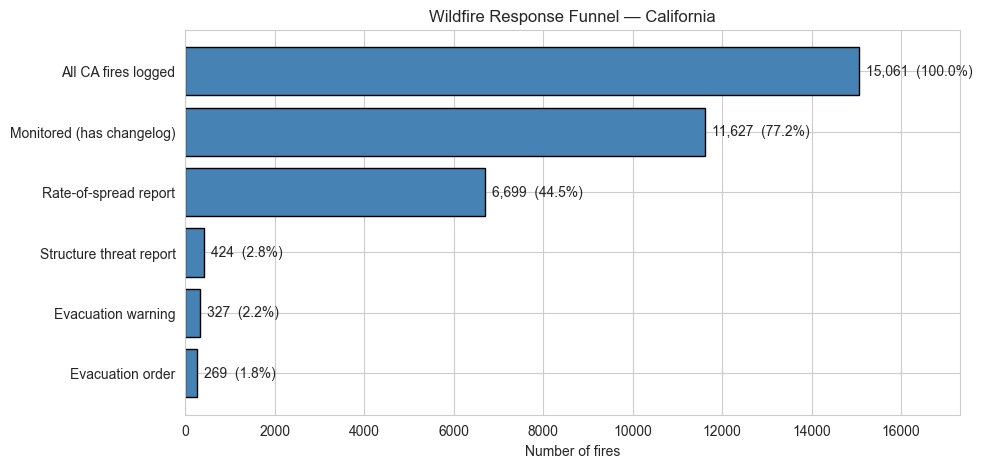


The four analysis populations:
  All fires:        15,061
  Monitored:        11,627
  With evac order:  269
  Evac order + ROS: 207  (modeling-ready set)


In [33]:
total = len(main)
funnel = {
    'All CA fires logged':       total,
    'Monitored (has changelog)': main['first_seen'].notna().sum(),
    'Rate-of-spread report':     (main['had_ros_report'] == 1).sum(),
    'Structure threat report':   (main['had_structure_threat'] == 1).sum(),
    'Evacuation warning':        (main['had_evac_warning'] == 1).sum(),
    'Evacuation order':          (main['had_evac_order'] == 1).sum(),
}

fig, ax = plt.subplots(figsize=(10, 5))
labels = list(funnel.keys())[::-1]
values = list(funnel.values())[::-1]
bars = ax.barh(labels, values, color='steelblue', edgecolor='black')

for bar, val in zip(bars, values):
    pct = val / total * 100
    ax.text(val + total*0.01, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({pct:.1f}%)', va='center', fontsize=10)

ax.set_xlabel('Number of fires')
ax.set_title('Wildfire Response Funnel — California')
ax.set_xlim(0, total * 1.15)
plt.savefig(FIG_DIR / '03_event_funnel.png')
plt.show()

print('\nThe four analysis populations:')
print(f'  All fires:        {total:,}')
print(f'  Monitored:        {funnel["Monitored (has changelog)"]:,}')
print(f'  With evac order:  {funnel["Evacuation order"]:,}')
both = ((main['had_evac_order']==1) & (main['had_ros_report']==1)).sum()
print(f'  Evac order + ROS: {both:,}  (modeling-ready set)')


**Result:** Of ~14,000 California fires, only a few hundred receive an evacuation order. Sample-size caveats matter and are flagged where each chart is interpreted.


## 9b. Fires per year

A sanity check on the time-coverage of the WatchDuty data


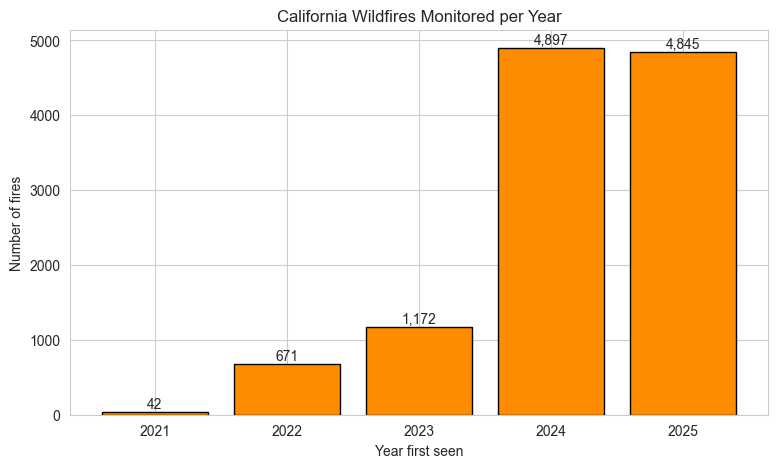

In [34]:
main['first_seen_dt'] = pd.to_datetime(main['first_seen'], errors='coerce', utc=True)
main['year'] = main['first_seen_dt'].dt.year

year_counts = main['year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(year_counts.index.astype(int).astype(str), year_counts.values,
              color='darkorange', edgecolor='black')
for bar, val in zip(bars, year_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 50,
            f'{int(val):,}', ha='center', fontsize=10)
ax.set_xlabel('Year first seen')
ax.set_ylabel('Number of fires')
ax.set_title('California Wildfires Monitored per Year')
plt.savefig(FIG_DIR / '03_fires_per_year.png')
plt.show()


**Result:** Coverage grows steeply from 2021 onward as WatchDuty's reporter network and ingestion pipeline matured. The bulk of evacuation-order fires is in 2024–2025.


## 9c. Reverse-geocoding to county

The bbox filter in Section 7a catches a few border-adjacent points that are technically in NV or OR. The offline `reverse_geocoder` library uses an internal city database to assign each (lat, lng) to its actual administrative state and county. This both cleans up the bbox edge cases and provides the `county` column the equity analysis joins on.

**Variables used:** `main['lat']`, `main['lng']`. Output: `main_ca` (geocoder-confirmed California fires), with `county` and `rg_state` columns.


Loading formatted geocoded file...
Fires confirmed in California by geocoding: 13,381 / 15,061
(The remainder fell just outside the border — NV, AZ, Baja — leftover from the lat/lng bounding box.)


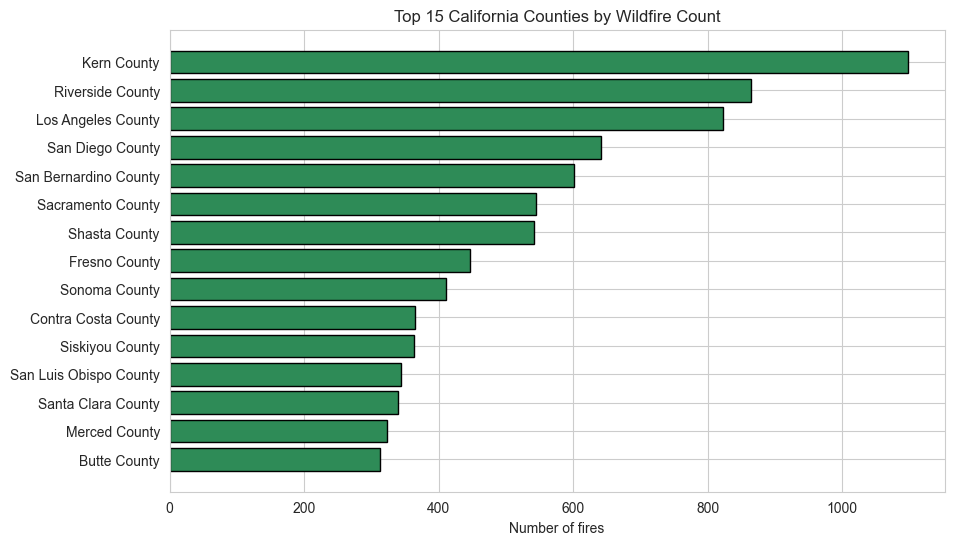

In [35]:
# Reverse-geocode each fire to a county (offline, no network needed)
coords = list(zip(main['lat'], main['lng']))
geo = rg.search(coords)
main['county'] = [g['admin2'] for g in geo]
main['rg_state'] = [g['admin1'] for g in geo]

# Keep only fires the geocoder confirms are in California
main_ca = main[main['rg_state'] == 'California'].copy()
print(f'Fires confirmed in California by geocoding: {len(main_ca):,} / {len(main):,}')
print(f'(The remainder fell just outside the border — NV, AZ, Baja — '
      f'leftover from the lat/lng bounding box.)')

top_counties = main_ca['county'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_counties.index[::-1], top_counties.values[::-1],
        color='seagreen', edgecolor='black')
ax.set_xlabel('Number of fires')
ax.set_title('Top 15 California Counties by Wildfire Count')
plt.savefig(FIG_DIR / '03_top_counties.png')
plt.show()


**Result:** Riverside, San Diego, Shasta, and Siskiyou lead: the four large counties that span California's main wildfire geographies (Southern coastal, desert, and Northern forest). 


## 9d. Rate-of-spread severity distribution

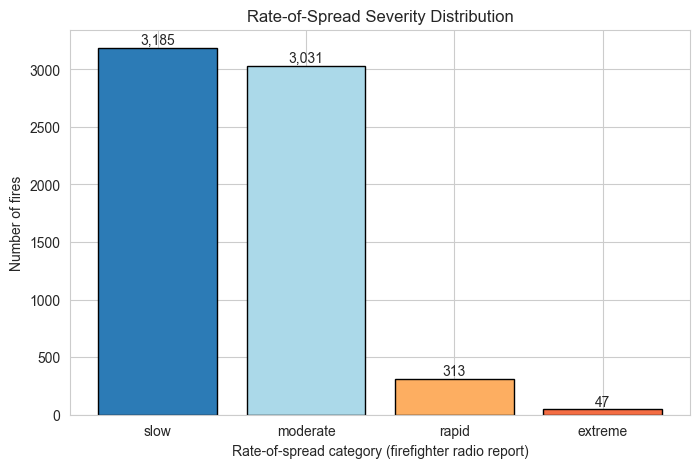

In [36]:
ros_order = ['slow', 'moderate', 'rapid', 'very_rapid', 'extreme']
ros_counts = main_ca['ros_value'].value_counts().reindex(ros_order).dropna()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2c7bb6', '#abd9e9', '#fdae61', '#f46d43', '#d7191c']
bars = ax.bar(ros_counts.index, ros_counts.values,
              color=colors[:len(ros_counts)], edgecolor='black')
for bar, val in zip(bars, ros_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 30,
            f'{int(val):,}', ha='center', fontsize=10)
ax.set_xlabel('Rate-of-spread category (firefighter radio report)')
ax.set_ylabel('Number of fires')
ax.set_title('Rate-of-Spread Severity Distribution')
plt.savefig(FIG_DIR / '03_ros_distribution.png')
plt.show()


**Result:** Most reported ROS values are "moderate" or "rapid"; "extreme" is rare. This is the radio-reported severity firefighters call in which is considered as a leading indicator that is in the data well before any evacuation decision is made.


## 9e. Alert-lag distribution

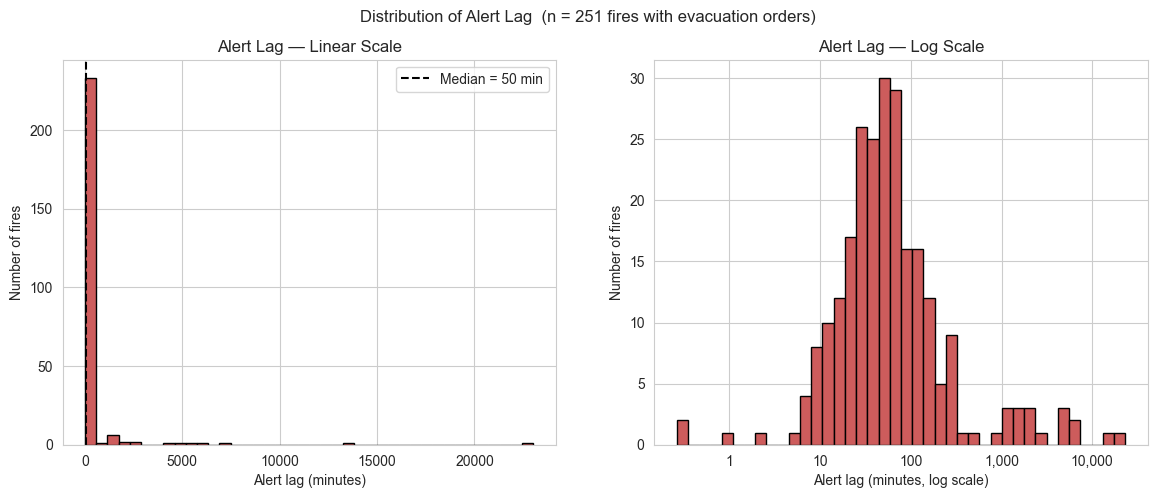

count      251.000000
mean       393.569010
std       1864.353879
min          0.000000
25%         24.744430
50%         49.873755
75%        102.259596
max      23021.583373
Name: alert_lag_mins, dtype: float64


In [37]:
evac = main_ca[(main_ca['had_evac_order'] == 1) &
               (main_ca['alert_lag_mins'] >= 0)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].hist(evac['alert_lag_mins'], bins=40, color='indianred', edgecolor='black')
axes[0].axvline(evac['alert_lag_mins'].median(), color='black',
                linestyle='--', label=f"Median = {evac['alert_lag_mins'].median():.0f} min")
axes[0].set_xlabel('Alert lag (minutes)')
axes[0].set_ylabel('Number of fires')
axes[0].set_title('Alert Lag — Linear Scale')
axes[0].legend()

# Log scale
positive = evac[evac['alert_lag_mins'] > 0]
axes[1].hist(np.log10(positive['alert_lag_mins']), bins=40,
             color='indianred', edgecolor='black')
axes[1].set_xlabel('Alert lag (log10 minutes)')
axes[1].set_ylabel('Number of fires')
axes[1].set_title('Alert Lag — Log Scale')
ticks = [0, 1, 2, 3, 4]
axes[1].set_xticks(ticks)
axes[1].set_xticklabels([f'{10**t:,.0f}' for t in ticks])
axes[1].set_xlabel('Alert lag (minutes, log scale)')

plt.suptitle(f'Distribution of Alert Lag  (n = {len(evac)} fires with evacuation orders)')
plt.savefig(FIG_DIR / '03_alert_lag_distribution.png')
plt.show()

print(evac['alert_lag_mins'].describe())


**Result:** Heavily right-skewed. Median is roughly 50 minutes; the tail extends past 24 hours. The log-scale panel shows the distribution is approximately log-normal centered around 30–100 minutes, which is the regime where most alerts are issued. The outliers in the tail are real fires and not errors.


## 9f. Alert lag by rate-of-spread severity

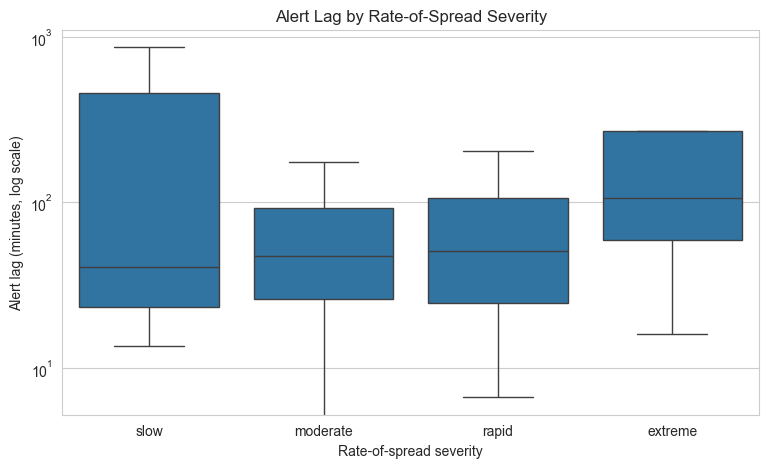

Median alert lag by severity:
ros_label
extreme     106.172643
moderate     47.518564
rapid        50.785148
slow         40.483741
Name: alert_lag_mins, dtype: float64


In [38]:
evac_ros = evac[evac['ros_severity'].notna()].copy()
sev_labels = {1: 'slow', 2: 'moderate', 3: 'rapid', 4: 'very_rapid', 5: 'extreme'}
evac_ros['ros_label'] = evac_ros['ros_severity'].map(sev_labels)

order = [l for l in ['slow','moderate','rapid','very_rapid','extreme']
         if l in evac_ros['ros_label'].values]

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=evac_ros, x='ros_label', y='alert_lag_mins',
            order=order, ax=ax, showfliers=False)
ax.set_yscale('log')
ax.set_xlabel('Rate-of-spread severity')
ax.set_ylabel('Alert lag (minutes, log scale)')
ax.set_title('Alert Lag by Rate-of-Spread Severity')
plt.savefig(FIG_DIR / '03_lag_by_ros.png')
plt.show()

print('Median alert lag by severity:')
print(evac_ros.groupby('ros_label', observed=True)['alert_lag_mins'].median())


**Result:** Faster-spreading fires receive their evacuation orders sooner which is consistent with reporters using ROS as a leading signal.


## 9g. Geographic distribution of evac-order fires (colored by lag)

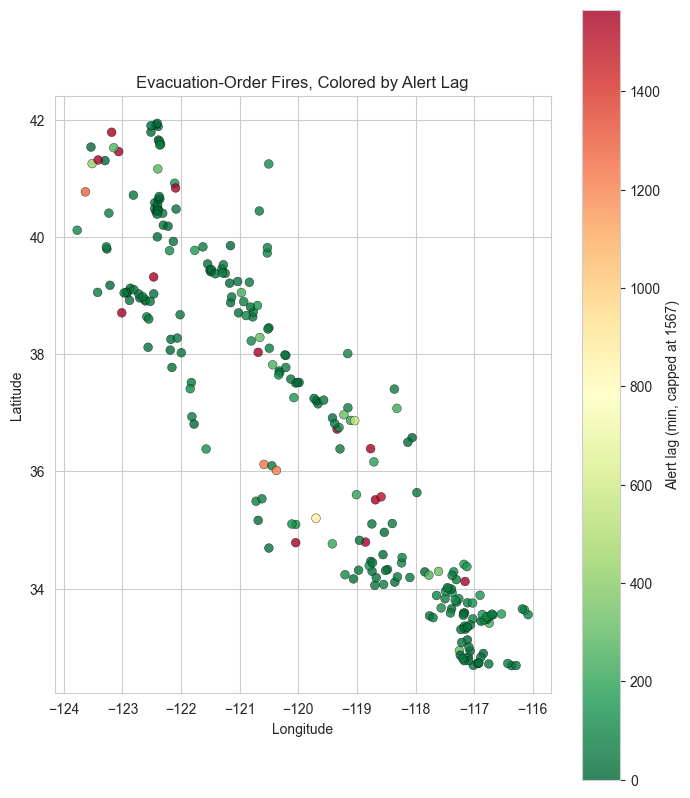

In [39]:
cap = evac['alert_lag_mins'].quantile(0.95)
evac_plot = evac.copy()
evac_plot['lag_capped'] = evac_plot['alert_lag_mins'].clip(upper=cap)

fig, ax = plt.subplots(figsize=(8, 10))
sc = ax.scatter(evac_plot['lng'], evac_plot['lat'],
                c=evac_plot['lag_capped'], cmap='RdYlGn_r',
                s=40, edgecolor='black', linewidth=0.3, alpha=0.8)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Evacuation-Order Fires, Colored by Alert Lag')
cbar = plt.colorbar(sc, label=f'Alert lag (min, capped at {cap:.0f})')
ax.set_aspect('equal')
plt.savefig(FIG_DIR / '03_geographic_evac_lag.png')
plt.show()


**Result:** A spatial scatter of the evac-order population alone. Red points are slow alerts (high lag); green are fast. Visually inspect the rural Northeast (Modoc, Lassen, Siskiyou) and inland counties, these are the regions where the equity gap shows up in Section 10.


---
# 10. Equity Analysis

The primary question of the project: does alert lag rise with community vulnerability? The four cells below aggregate SVI to the county level (with population weighting), join it to the fires, and produce the headline equity chart.


## 10a. County-level SVI aggregation (population-weighted)

The SVI ships at the census-tract level (~9,100 California tracts). Fires are matched to counties via the `reverse_geocoder` step in 9c, so SVI needs to roll up to county too.

**Why population-weighted?** LA County has ~2,495 tracts; Modoc has 9. An unweighted average would let small rural counties dominate the SVI distribution. Weighting by `E_TOTPOP` makes the county-level SVI reflect what a randomly chosen Californian in that county would experience.

**Variables used:** `cdc` (the lean SVI). Output: `county_svi` (one row per CA county).


In [40]:
def wavg(group, col):
    """Population-weighted average of `col`, ignoring NaN values."""
    valid = group[col].notna()
    if valid.sum() == 0 or group.loc[valid, 'E_TOTPOP'].sum() == 0:
        return np.nan
    return np.average(group.loc[valid, col], weights=group.loc[valid, 'E_TOTPOP'])

county_svi = cdc.groupby('COUNTY').apply(lambda g: pd.Series({
    'county_pop':  g['E_TOTPOP'].sum(),
    'n_tracts':    len(g),
    'rpl_themes':  wavg(g, 'RPL_THEMES'),
    'rpl_theme1':  wavg(g, 'RPL_THEME1'),
    'rpl_theme2':  wavg(g, 'RPL_THEME2'),
    'rpl_theme3':  wavg(g, 'RPL_THEME3'),
    'rpl_theme4':  wavg(g, 'RPL_THEME4'),
    'ep_limeng':   wavg(g, 'EP_LIMENG'),
    'ep_noveh':    wavg(g, 'EP_NOVEH'),
    'ep_age65':    wavg(g, 'EP_AGE65'),
    'ep_disabl':   wavg(g, 'EP_DISABL'),
    'ep_pov150':   wavg(g, 'EP_POV150'),
    'ep_noint':    wavg(g, 'EP_NOINT'),
}), include_groups=False).reset_index()

print(f'Aggregated {len(cdc):,} tracts into {len(county_svi)} counties')
county_svi.sort_values('rpl_themes', ascending=False).head(10)


Aggregated 9,109 tracts into 58 counties


,COUNTY,county_pop,n_tracts,rpl_themes,rpl_theme1,rpl_theme2,rpl_theme3,rpl_theme4,ep_limeng,ep_noveh,ep_age65,ep_disabl,ep_pov150,ep_noint
12,Imperial County,179578.0,40.0,0.788171,0.753722,0.851034,0.831129,0.571725,19.701931,7.630732,13.183832,14.425173,36.667927,13.318232
23,Merced County,282290.0,63.0,0.730119,0.738385,0.797651,0.621307,0.530855,13.767638,6.832054,11.412082,12.768820,29.937172,10.639908
5,Colusa County,21811.0,6.0,0.704472,0.649627,0.818587,0.516396,0.574281,14.650653,4.434561,15.135588,13.136624,22.596781,19.219701
53,Tulare County,473446.0,103.0,0.691982,0.695847,0.752420,0.609070,0.546601,12.728981,4.631108,11.482106,11.847990,31.455797,14.572033
19,Madera County,157243.0,34.0,0.682151,0.705956,0.749793,0.555993,0.493263,12.544735,4.743125,14.175660,14.007375,31.160045,11.680837
10,Glenn County,28657.0,8.0,0.667138,0.698603,0.686233,0.342217,0.591148,8.018386,3.609701,16.870129,12.660840,25.924476,13.717469
22,Mendocino County,91145.0,23.0,0.666147,0.667073,0.762673,0.207043,0.617687,4.436447,8.011515,23.263567,18.744751,25.377297,13.927152
9,Fresno County,1008280.0,225.0,0.653249,0.642692,0.698035,0.601470,0.555379,10.250260,7.291924,12.467821,12.974072,30.964114,14.927758
50,Sutter County,99101.0,21.0,0.646115,0.595552,0.797549,0.410929,0.569115,9.633954,5.263969,15.708430,13.807478,23.616905,12.239595
15,Kings County,152515.0,31.0,0.624978,0.653359,0.695937,0.564544,0.485547,10.279974,4.850552,10.471392,12.299385,27.699091,13.360099


**Result:** 58 California counties, each with a population-weighted SVI composite and the six access-barrier percentages.


## 10b. Top 15 most vulnerable counties

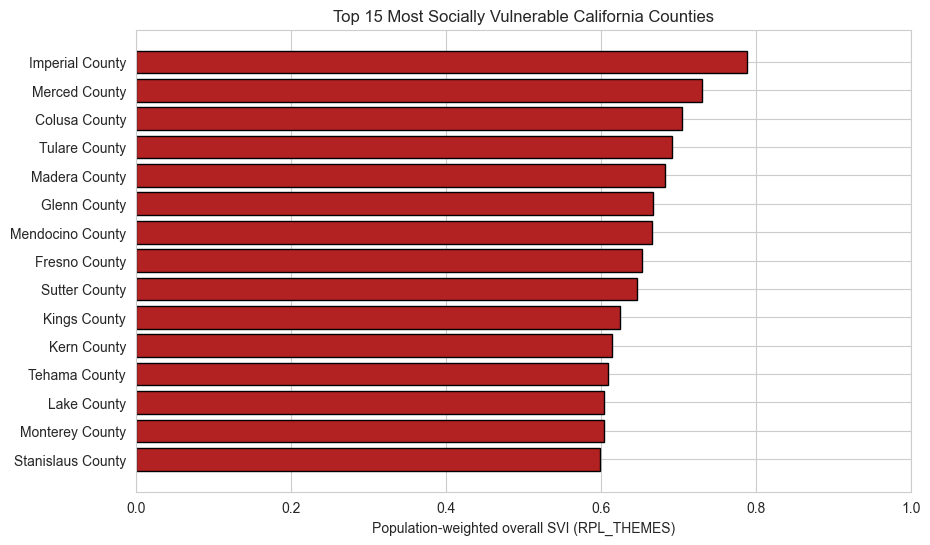

In [41]:
top_vuln = county_svi.nlargest(15, 'rpl_themes')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_vuln['COUNTY'][::-1], top_vuln['rpl_themes'][::-1],
               color='firebrick', edgecolor='black')
ax.set_xlabel('Population-weighted overall SVI (RPL_THEMES)')
ax.set_title('Top 15 Most Socially Vulnerable California Counties')
ax.set_xlim(0, 1)
plt.savefig(FIG_DIR / '03_top_vulnerable_counties.png')
plt.show()


**Result:** Imperial, Tulare, Merced, and several Central-Valley counties top the list.


## 10c. Merge SVI onto fires

In [42]:
merged = main_ca.merge(county_svi, left_on='county', right_on='COUNTY', how='left')

print(f'Merged table: {merged.shape[0]:,} rows x {merged.shape[1]} cols')
print(f'Fires with SVI matched:        {merged["rpl_themes"].notna().sum():,}')
print(f'Fires with evac order + SVI:   '
      f'{((merged["had_evac_order"]==1) & merged["rpl_themes"].notna()).sum()}')

merged.to_csv(DATA_DIR / 'merged_fire_svi.csv', index=False)
print('\nSaved merged_fire_svi.csv')


Merged table: 13,381 rows x 46 cols
Fires with SVI matched:        13,381
Fires with evac order + SVI:   251

Saved merged_fire_svi.csv


**Result:** ~14,000 fires now carry their surrounding county's population-weighted SVI. Of those, ~250 also have an evacuation order.

> **Note on counts:** the reverse-geocode + county-SVI join keeps only fires that resolve to a California county with an SVI score, so the modeling table (`merged_fire_svi.csv`, ~13,400 fires) is slightly smaller than the full monitored set (~15,000); the evacuation-order population (~250) is essentially unchanged.

## 10d. Significant Finding: Alert lag by county vulnerability quartile

The equity finding. Fires are split into quartiles by their county's population-weighted SVI; alert lag is shown by quartile as both a boxplot (log scale, robust to the long right tail) and a bar of means (sensitive to the tail).

**Why show both?** The median is much more stable than the mean given small per-quartile samples (~30–95 fires). We report the median to be honest about typical behavior, while the mean view shows the long-tail effect.

**Variables used:** `merged` (from 10c).


Alert lag by county vulnerability quartile:
                        count  median   mean
vuln_quartile                               
Q1\n(least vulnerable)     69    43.6  155.4
Q2                         65    60.9  277.4
Q3                         62    53.6  421.1
Q4\n(most vulnerable)      55    47.5  798.7


/var/folders/8m/h9g8ftgs3cx497skswkj3nmw0000gn/T/ipykernel_24708/2938294287.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=evac_eq, x='vuln_quartile', y='alert_lag_mins',


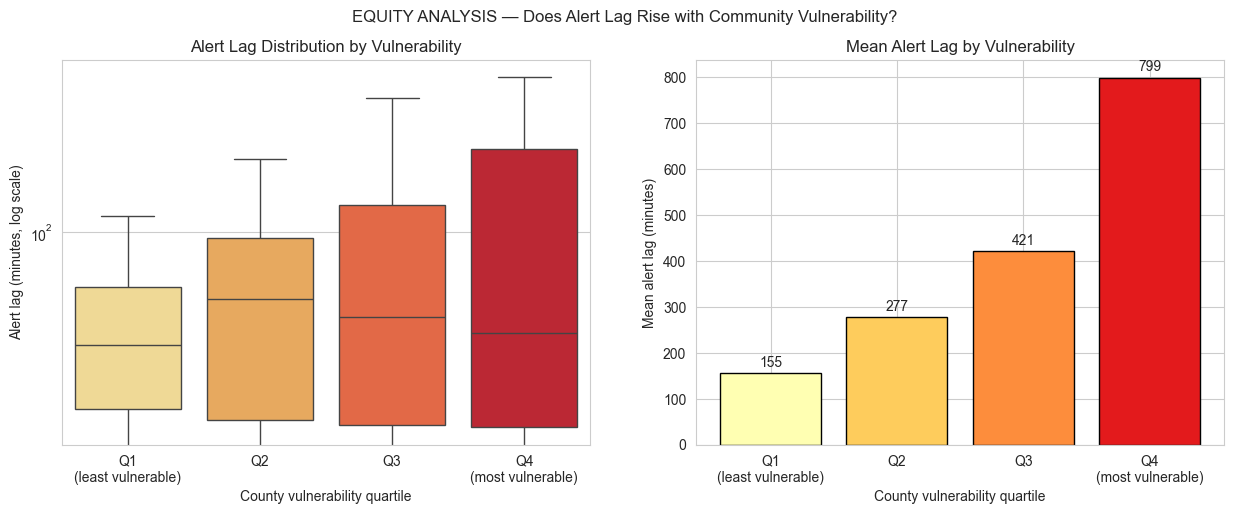

In [43]:
evac_eq = merged[(merged['had_evac_order'] == 1) &
                 (merged['alert_lag_mins'] >= 0) &
                 (merged['rpl_themes'].notna())].copy()

evac_eq['vuln_quartile'] = pd.qcut(
    evac_eq['rpl_themes'], 4,
    labels=['Q1\n(least vulnerable)', 'Q2', 'Q3', 'Q4\n(most vulnerable)']
)

summary = evac_eq.groupby('vuln_quartile', observed=True)['alert_lag_mins'].agg(
    ['count', 'median', 'mean'])
print('Alert lag by county vulnerability quartile:')
print(summary.round(1))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot (median + spread)
sns.boxplot(data=evac_eq, x='vuln_quartile', y='alert_lag_mins',
            ax=axes[0], showfliers=False, palette='YlOrRd')
axes[0].set_yscale('log')
axes[0].set_xlabel('County vulnerability quartile')
axes[0].set_ylabel('Alert lag (minutes, log scale)')
axes[0].set_title('Alert Lag Distribution by Vulnerability')

# Bar chart of means
bars = axes[1].bar(range(4), summary['mean'], color=['#ffffb2','#fecc5c','#fd8d3c','#e31a1c'],
                   edgecolor='black')
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(summary.index)
axes[1].set_xlabel('County vulnerability quartile')
axes[1].set_ylabel('Mean alert lag (minutes)')
axes[1].set_title('Mean Alert Lag by Vulnerability')
for bar, val in zip(bars, summary['mean']):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+15,
                 f'{val:.0f}', ha='center', fontsize=10)

plt.suptitle('EQUITY ANALYSIS — Does Alert Lag Rise with Community Vulnerability?')
plt.savefig(FIG_DIR / '03_equity_lag_by_vulnerability.png')
plt.show()


**Result:**

- **Medians are flat across quartiles** (~40–65 min). At the median level, fires in the most-vulnerable counties are *not* alerted measurably later than fires in the least-vulnerable counties.
- **Means rise sharply with vulnerability**: from ~140 min in Q1 to ~800 min in Q4. The most-vulnerable quartile has fatter right tails: occasionally an alert that takes a day or two, dragging the mean.



---
# 10.5 Nini's Analysis/Approach

**Variables:** `geoevent`, `geo_ca`, `cl`, `evac_zone`, `evac_cl`, `fire_pm`, `evaczone`, `first_evac`, `timing`, and the helper `all_keys()`.


In [44]:
geoevent = geo_events.copy()              # full geo_events table 
cl = geo_changelog.copy()                  # geo_event changelog
evac_zone = evac_zones.copy()             # evac zones master
evac_cl = evac_changelog.copy()            # evac zone changelog
evaczone = evac_zones.copy()              
fire_pm = fire_perimeters.copy()           # fire perimeters



def _parse_data(d):
    try:
        return json.loads(d)
    except (json.JSONDecodeError, TypeError):
        return {}

geoevent['data_parsed'] = geoevent['data'].apply(_parse_data)
geoevent['acreage']     = geoevent['data_parsed'].apply(lambda x: x.get('acreage'))
geoevent['containment'] = geoevent['data_parsed'].apply(lambda x: x.get('containment'))
geoevent['is_fps']      = geoevent['data_parsed'].apply(lambda x: x.get('is_fps'))
geoevent['is_prescribed'] = geoevent['data_parsed'].apply(lambda x: x.get('is_prescribed'))

# === has_evac via changelog ===
def _is_any_evac(changes_str):
    try:
        changes = json.loads(changes_str)
        evac_keys = ['data.evacuation_orders', 'data.evacuation_warnings', 'data.evacuation_advisories']
        return any(k in changes for k in evac_keys)
    except Exception:
        return False

ever_had_evac_ids = set(cl[cl['changes'].apply(_is_any_evac)]['geo_event_id'])
geoevent['has_evac'] = geoevent['id'].isin(ever_had_evac_ids).astype(int)

# === Drop locations + prescribed ===
geoevent = geoevent[geoevent['geo_event_type'] == 'wildfire']
geoevent = geoevent[geoevent['is_prescribed'] != True]
print(f'Wildfires after dropping locations + prescribed: {len(geoevent):,}')

# === Size groups ===
geoevent['size_group'] = pd.cut(
    geoevent['acreage'],
    bins=[0, 10, 100, 1000, float('inf')],
    labels=['Small (<10)', 'Medium (10-100)', 'Large (100-1000)', 'Major (>1000)']
)

# === date_created → datetime; CA-only subset via lat/lng bbox ===
cl['date_created'] = pd.to_datetime(cl['date_created'], utc=True, errors='coerce')
geoevent['date_created'] = pd.to_datetime(geoevent['date_created'], utc=True, errors='coerce')

# Reverse-geocode CA fires to county
coords_n = list(zip(geoevent['lat'], geoevent['lng']))
geo_n = rg.search(coords_n)
geoevent['county'] = [r['admin2'].replace(' County', '').strip() for r in geo_n]

geo_ca = geoevent[
    geoevent['lat'].between(32, 42) &
    geoevent['lng'].between(-124, -114)
].copy()
print(f'CA-only subset (geo_ca): {len(geo_ca):,} fires; has_evac sum: {geo_ca["has_evac"].sum():,}')

# === `all_keys()` helper ===
def all_keys(c):
    try:
        return list(json.loads(c).keys())
    except Exception:
        return []

# === field column for changelog ===
def first_key(c):
    try:
        return list(json.loads(c).keys())[0]
    except Exception:
        return None
cl['field'] = cl['changes'].apply(first_key)


Wildfires after dropping locations + prescribed: 50,664
CA-only subset (geo_ca): 15,218 fires; has_evac sum: 376


In [45]:
# === first_evac + timing ===
def is_first_evac(changes_str):
    try:
        changes = json.loads(changes_str)
        evac_keys = ['data.evacuation_orders', 'data.evacuation_warnings', 'data.evacuation_advisories']
        for key in evac_keys:
            if key in changes:
                if changes[key][0] is None and changes[key][1] is not None:
                    return True
        return False
    except Exception:
        return False

first_evac = (
    cl[cl['changes'].apply(is_first_evac)]
    .groupby('geo_event_id')['date_created']
    .min()
    .reset_index()
    .rename(columns={'date_created': 'first_evac_time'})
)

timing = first_evac.merge(
    geoevent[['id', 'date_created', 'acreage', 'size_group']],
    left_on='geo_event_id',
    right_on='id',
    how='left'
)
timing['hours_to_evac'] = (
    (timing['first_evac_time'] - pd.to_datetime(timing['date_created'], utc=True))
    .dt.total_seconds() / 3600
)
timing = timing[timing['hours_to_evac'] >= 0]          # remove negative-time anomalies
timing = timing[timing['hours_to_evac'] < 108]         # remove >5 day outliers

print(f'Fires with first-evac time: {len(timing):,}')
print('Median hours to first evacuation alert by fire size:')
print(timing.groupby('size_group', observed=True)['hours_to_evac'].agg(['median', 'count']).round(1))


Fires with first-evac time: 915
Median hours to first evacuation alert by fire size:
                  median  count
size_group                     
Small (<10)          0.5    161
Medium (10-100)      0.8    244
Large (100-1000)     1.2    200
Major (>1000)        3.4    258


**Finding:** The largest fires take the longest to receive first evacuation alerts (median: 3.4 hours), compared to just 0.5 hours for the smallest fires

> **Author:** Wang Yu Wen


## What do reporters update before issuing an evacuation alert?

> **Author:** Yu-Wen Wang 


In [46]:
evac_fire_ids = geoevent[geoevent['has_evac'] == 1]['id'].tolist()
cl_evac = cl[cl['geo_event_id'].isin(evac_fire_ids)].copy()
cl_evac = cl_evac.merge(
    first_evac[['geo_event_id', 'first_evac_time']],
    on='geo_event_id'
)
cl_evac = cl_evac[cl_evac['date_created'] < cl_evac['first_evac_time']]

top_fields = cl_evac['field'].value_counts().head(10)


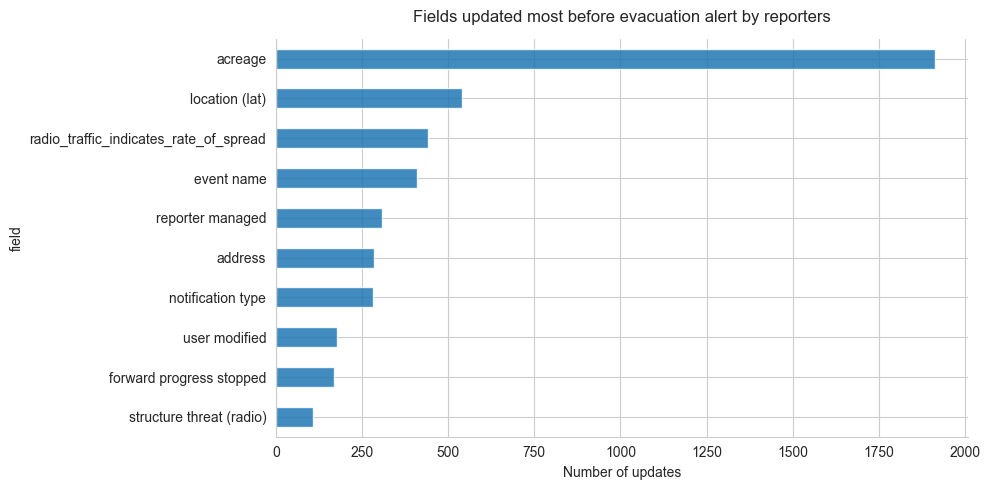

In [47]:
name_map = {
    'data.acreage': 'acreage',
    'user_modified_id': 'user modified',
    'data.containment': 'containment',
    'address': 'address',
    'reporter_managed': 'reporter managed',
    'lat': 'location (lat)',
    'name': 'event name',
    'data.is_fps': 'forward progress stopped',
    'radio_traffic_indicates_structure_threat': 'structure threat (radio)',
    'notification_type': 'notification type',
}

top_fields_clean = top_fields.rename(index=name_map)

fig, ax = plt.subplots(figsize=(10, 5))
top_fields_clean.sort_values().plot(kind='barh', ax=ax, alpha=0.85)

ax.set_title('Fields updated most before evacuation alert by reporters', fontsize=12, pad=12)
ax.set_xlabel('Number of updates')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


**Finding:** Acreage (fire size) is the primary signal reporters use to decide whether to escalate to an evacuation alert.

> **Author:** Wang Yu Wen


---
# 11. Escalation Pattern Analysis

> **Author:** Wang Yu Wen


### Escalation Pattern Analysis
The Eaton Fire issued evacuation orders **before** warnings, skipping the expected advisory → warning → order sequence. Is this pattern an anomaly, or is it common across all fires?

**Method:** Using `evac_zones_gis_evaczonechangelog`, the first time each evacuation zone was activated (status changed from `null` to `advisory/warning/order`) was extracted per fire. Fires were then classified by the order in which they first issued each level of alert.

**Join:** `evac_zone_id` (evac_cl) → `uid_v2` (evac_zone) → `geo_event_id` (evac_map)



In [48]:
# Parse all status change events from changelog
status_changes = []
for _, row in evac_cl.iterrows():
    try:
        c = json.loads(row['changes'])
        if 'status' in c:
            status_changes.append({
                'evac_zone_id': row['evac_zone_id'],
                'date_created':  row['date_created'],
                'from_status':   c['status'][0],
                'to_status':     c['status'][1]
            })
    except:
        pass

sc = pd.DataFrame(status_changes)
sc['date_created'] = pd.to_datetime(sc['date_created'], utc=True)

# Join: (evac_zone_id -> uid_v2 -> geo_event_id)
zone_to_uid = evac_zone[['id', 'uid_v2']].rename(columns={'id': 'evac_zone_id'})
uid_to_fire  = evac_map[['uid_v2', 'geo_event_id']]

sc2 = sc.merge(zone_to_uid, on='evac_zone_id', how='left') \
        .merge(uid_to_fire,  on='uid_v2',       how='left')

# Keep only first-activation events (from_status == null: zone activated for first time)
activations = sc2[
    sc2['from_status'].isna() &
    sc2['geo_event_id'].notna()
].copy()
activations['geo_event_id'] = activations['geo_event_id'].astype(int)

# For each fire, get the earliest timestamp per escalation level
first_per_level = (
    activations
    .groupby(['geo_event_id', 'to_status'])['date_created']
    .min()
    .unstack()
    .rename(columns={
        'advisories': 'first_advisory',
        'warnings':   'first_warning',
        'orders':     'first_order'
    })
)

# Classify escalation pattern per fire
def classify_pattern(row):
    has_a = pd.notna(row.get('first_advisory'))
    has_w = pd.notna(row.get('first_warning'))
    has_o = pd.notna(row.get('first_order'))

    if not has_o:
        return 'no_order'
    if not has_w and not has_a:
        return 'order_only'
    if has_w and not has_a:
        return 'warning_then_order' if row['first_warning'] < row['first_order'] \
               else 'order_first'
    if has_a and has_w:
        times = sorted([
            ('advisory', row['first_advisory']),
            ('warning',  row['first_warning']),
            ('order',    row['first_order'])
        ], key=lambda x: x[1])
        seq = [t[0] for t in times]
        if seq == ['advisory', 'warning', 'order']:
            return 'gradual (Advisory → Warning → Order)'
        elif seq[0] == 'order':
            return 'order_first'
        else:
            return 'mixed'
    return 'mixed'

first_per_level['pattern'] = first_per_level.apply(classify_pattern, axis=1)

# Print results
has_order = first_per_level[first_per_level['first_order'].notna()]

print(f"Total fires with zone-level data: {len(first_per_level)}")
print(f"Fires that issued an evacuation order: {len(has_order)}")
print()
print("Escalation pattern breakdown:")
print(has_order['pattern'].value_counts())
print()

pct_gradual  = (has_order['pattern'] == 'gradual (Advisory → Warning → Order)').mean() * 100
pct_no_prior = has_order['pattern'].isin(
    ['order_only', 'order_first', 'order_then_warning']
).mean() * 100

print(f"1. {pct_gradual:.1f}% of fires followed the gradual (Advisory→Warning→Order) escalation")
print(f"2. {pct_no_prior:.1f}% of evacuation orders were issued without any prior warning or advisory")


Total fires with zone-level data: 268
Fires that issued an evacuation order: 145

Escalation pattern breakdown:
pattern
order_first                             59
order_only                              34
warning_then_order                      34
mixed                                   15
gradual (Advisory → Warning → Order)     3
Name: count, dtype: int64

1. 2.1% of fires followed the gradual (Advisory→Warning→Order) escalation
2. 64.1% of evacuation orders were issued without any prior warning or advisory


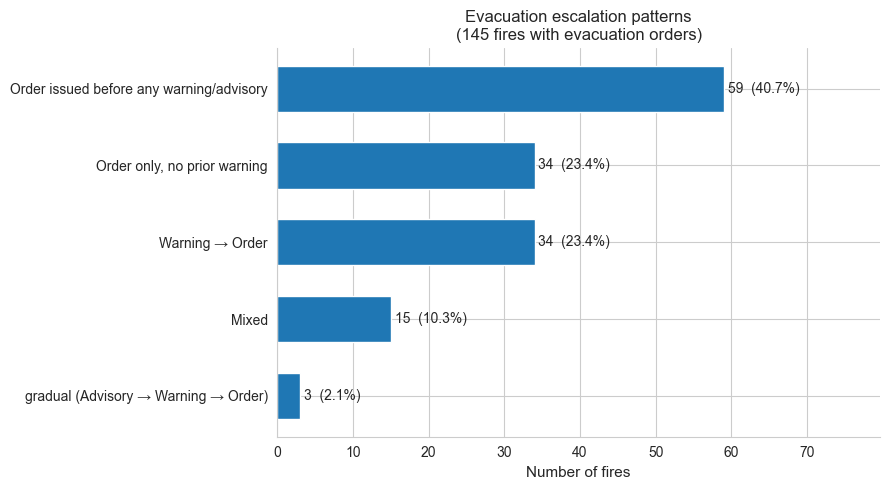

In [49]:
fig, ax = plt.subplots(figsize=(9, 5))

# Calculate directly from data
pattern_counts = has_order['pattern'].value_counts()
total = len(has_order)

# Define display order and labels
order = [
    'order_first',
    'order_only',
    'warning_then_order',
    'mixed',
    'gradual (Advisory → Warning → Order)'
]
label_map = {
    'order_first':        'Order issued before any warning/advisory',
    'order_only':         'Order only, no prior warning',
    'warning_then_order': 'Warning → Order',
    'mixed':              'Mixed',
    'gradual (Advisory → Warning → Order)':    'gradual (Advisory → Warning → Order)'
}

# Only include patterns that exist in data
order = [p for p in order if p in pattern_counts.index]
counts = [pattern_counts[p] for p in order]
labels = [label_map[p] for p in order]

bars = ax.barh(labels, counts, edgecolor='white', height=0.6)

for bar, count in zip(bars, counts):
    pct = count / total * 100
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{count}  ({pct:.1f}%)', va='center', fontsize=10)

ax.invert_yaxis()
ax.set_xlim(0, max(counts) * 1.35)
ax.set_xlabel('Number of fires', fontsize=11)
ax.set_title(f'Evacuation escalation patterns\n({total} fires with evacuation orders)',
             fontsize=12)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / 'escalation_patterns.png', dpi=150, bbox_inches='tight')
plt.show()


**Findings:**

1. Only **2.1%** of fires followed the expected gradual (Advisory → Warning → Order) escalation sequence.
2. **64.1%** of evacuation orders were issued without any prior warning or advisory, meaning the system designed around gradual escalation rarely reflects what actually happens on the ground.


**Eaton Fire:** Skipping the standard escalation order is not an anomaly but the norm, which shows the need for an earlier, signal-based trigger that does not rely on the escalation system working as designed.

> **Author:** Yu-Wen Wang


---
# 12. Fire Perimeter vs Evacuation Order Timing

> **Author:** Yu-Wen Wang


### Fire Perimeter vs Evacuation Order Timing
Using `fire_perimeters_gis_fireperimeter`, the timing of the first approved fire perimeter was compared against the first evacuation order across 258 fires



Fires with both perimeter and evacuation data: 258

Was a fire perimeter available before the evacuation order?
  Yes (perimeter came first): 49 fires (19.0%)
  No  (evac order came first): 209 fires (81.0%)

Median hrs to perimeter: 7.5 hrs
Median hrs to evac order: 1.4 hrs



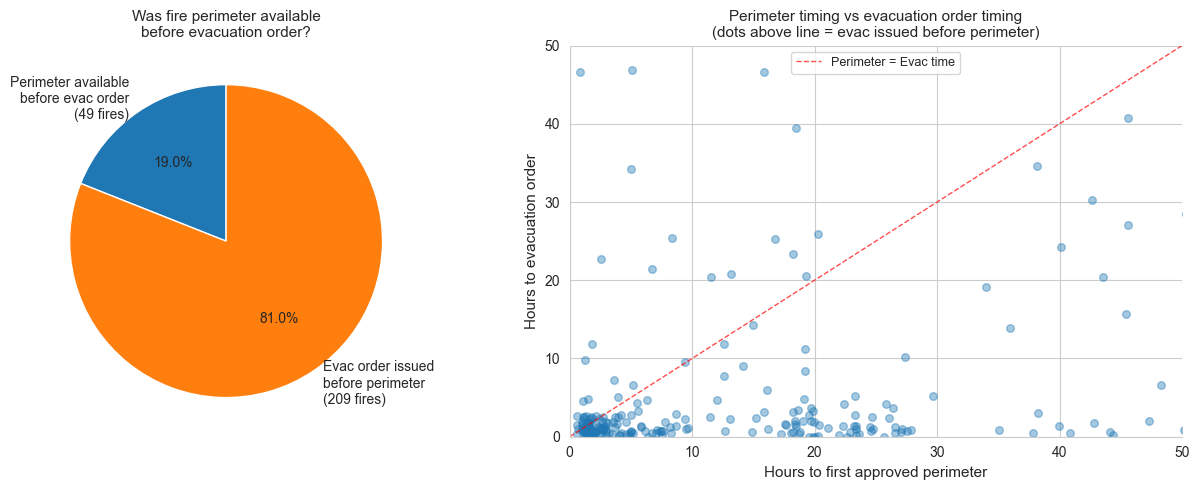

In [50]:
fp_approved = fire_pm[fire_pm['approval_status'] == 'approved'].copy()
fp_approved['date_created'] = pd.to_datetime(fp_approved['date_created'], utc=True)

# Get earliest approved perimeter per fire
first_perimeter = fp_approved.groupby('geo_event_id')['date_created'].min() \
    .reset_index().rename(columns={'date_created': 'first_perimeter_time'})

# Join with timing (hours_to_evac)
perim_timing = timing.merge(first_perimeter, on='geo_event_id', how='inner')

# Calculate hours from fire creation to first perimeter
perim_timing['date_created'] = pd.to_datetime(perim_timing['date_created'], utc=True)
perim_timing['first_perimeter_time'] = pd.to_datetime(perim_timing['first_perimeter_time'], utc=True)

perim_timing['hrs_to_perimeter'] = (
    perim_timing['first_perimeter_time'] - perim_timing['date_created']
).dt.total_seconds() / 3600

# Filter outliers
perim_timing = perim_timing[perim_timing['hrs_to_perimeter'].between(0, 200)]

# Was perimeter available before the evacuation order?
perim_timing['perimeter_before_evac'] = (
    perim_timing['hrs_to_perimeter'] < perim_timing['hours_to_evac']
)

print(f"Fires with both perimeter and evacuation data: {len(perim_timing)}")
print()
print("Was a fire perimeter available before the evacuation order?")
vc = perim_timing['perimeter_before_evac'].value_counts()
print(f"  Yes (perimeter came first): {vc.get(True, 0)} fires ({vc.get(True,0)/len(perim_timing)*100:.1f}%)")
print(f"  No  (evac order came first): {vc.get(False,0)} fires ({vc.get(False,0)/len(perim_timing)*100:.1f}%)")
print()
print(f"Median hrs to perimeter: {perim_timing['hrs_to_perimeter'].median():.1f} hrs")
print(f"Median hrs to evac order: {perim_timing['hours_to_evac'].median():.1f} hrs")
print()

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Chart 1: Pie chart
sizes = [vc.get(True, 0), vc.get(False, 0)]
labels = [
    f'Perimeter available\nbefore evac order\n({vc.get(True,0)} fires)',
    f'Evac order issued\nbefore perimeter\n({vc.get(False,0)} fires)'
]
colors = ['#1D9E75', '#E24B4A']
axes[0].pie(sizes, labels=labels,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 10})
axes[0].set_title('Was fire perimeter available\nbefore evacuation order?',
                  fontsize=11)

# Chart 2: Scatter - hrs to perimeter vs hrs to evac
axes[1].scatter(
    perim_timing['hrs_to_perimeter'],
    perim_timing['hours_to_evac'],
    alpha=0.4, s=30
)
# Diagonal line (perimeter = evac time)
max_val = min(perim_timing[['hrs_to_perimeter','hours_to_evac']].max().max(), 50)
axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=1, alpha=0.7,
             label='Perimeter = Evac time')
axes[1].set_xlabel('Hours to first approved perimeter', fontsize=11)
axes[1].set_ylabel('Hours to evacuation order', fontsize=11)
axes[1].set_title('Perimeter timing vs evacuation order timing\n(dots above line = evac issued before perimeter)',
                  fontsize=11)
axes[1].set_xlim(0, 50)
axes[1].set_ylim(0, 50)
axes[1].legend(fontsize=9)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / 'perimeter_timing.png', dpi=150, bbox_inches='tight')
plt.show()


**Findings:**
- **81%** of evacuation orders were issued before any approved fire perimeter existed
- Median time to first perimeter: **7.5 hours** v.s median time to evac order: **1.4 hours**
- Reporters are making life-safety decisions **5x before** a mapped fire boundary is available

**Implication:** Evacuation decisions rely almost entirely on non-spatial early signals, not mapped boundaries



---
# 13. Evacuation Zone Repeated Exposure Analysis (CA only)

> **Author:** Yu-Wen Wang


### Evacuation Zone Repeated Exposure Analysis (CA only)

Using `evac_zone_status_geo_event_map` and `evac_zones_gis_evaczone`, each evacuation zone was matched to how many fires triggered its activation



Total evacuation zones: 37458
Zones activated at least once: 3159
Zones activated 3+ times: 36
Zones activated 5+ times: 0

Top 15 most repeatedly activated zones:
display_name   dataset_name  fire_count
    SIS-3315 siskiyou-CA_US         4.0
    SIS-3318 siskiyou-CA_US         4.0
     UMC-317 umatilla-OR_US         4.0
     UMC-311 umatilla-OR_US         4.0
     UMC-327 umatilla-OR_US         4.0
     UMC-323 umatilla-OR_US         4.0
     UMC-303 umatilla-OR_US         4.0
     UMC-305 umatilla-OR_US         4.0
     UMC-309 umatilla-OR_US         4.0
     UMC-319 umatilla-OR_US         4.0
     UMC-301 umatilla-OR_US         4.0
     UMC-315 umatilla-OR_US         4.0
     UMC-307 umatilla-OR_US         4.0
    SIS-3413 siskiyou-CA_US         4.0
     UMC-325 umatilla-OR_US         4.0

CA counties with most repeatedly activated zones (3+ fires):
             repeated_zones  total_activations
county                                        
Siskiyou                  9             

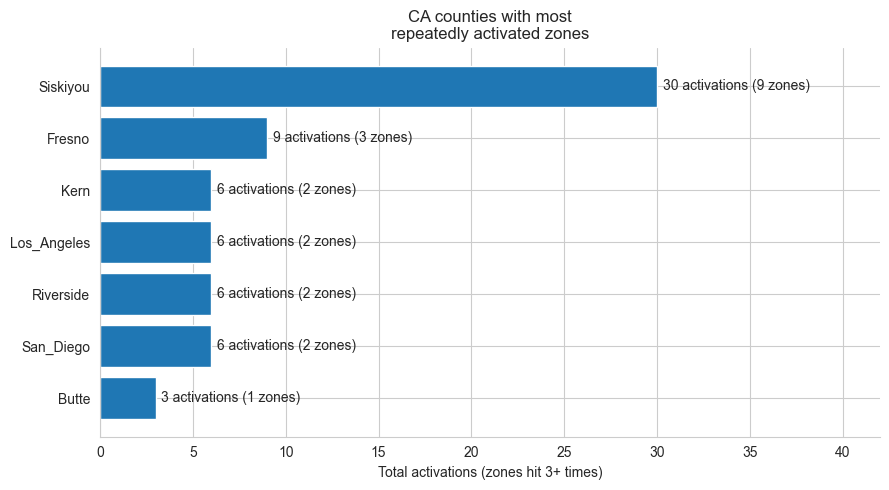

In [51]:
zone_freq = evac_map.groupby('uid_v2').size().reset_index(name='fire_count')
ez_freq = evaczone.merge(zone_freq, on='uid_v2', how='left').fillna(0)

print(f"Total evacuation zones: {len(ez_freq)}")
print(f"Zones activated at least once: {(ez_freq['fire_count'] > 0).sum()}")
print(f"Zones activated 3+ times: {(ez_freq['fire_count'] >= 3).sum()}")
print(f"Zones activated 5+ times: {(ez_freq['fire_count'] >= 5).sum()}")
print()

# Top repeatedly hit zones
repeatedly_hit = ez_freq[ez_freq['fire_count'] >= 3].copy()
print("Top 15 most repeatedly activated zones:")
print(repeatedly_hit.sort_values('fire_count', ascending=False)
      [['display_name', 'dataset_name', 'fire_count']].head(15).to_string(index=False))
print()

# By county - which counties have the most repeatedly hit zones?
ez_freq['county'] = ez_freq['dataset_name'] \
    .str.replace('-CA_US.*', '', regex=True) \
    .str.replace('-', ' ').str.title()

ca_repeated = ez_freq[
    ez_freq['dataset_name'].str.contains('-CA_US', na=False) &
    (ez_freq['fire_count'] >= 3)
].groupby('county').agg(
    repeated_zones=('uid_v2', 'count'),
    total_activations=('fire_count', 'sum')
).sort_values('total_activations', ascending=False)

print("CA counties with most repeatedly activated zones (3+ fires):")
print(ca_repeated.head(10).to_string())

fig, ax = plt.subplots(figsize=(9, 5))

ca_repeated_plot = ca_repeated.head(7).copy()
ax.barh(ca_repeated_plot.index, ca_repeated_plot['total_activations'])
ax.set_xlabel('Total activations (zones hit 3+ times)')
ax.set_title('CA counties with most\nrepeatedly activated zones')

for i, (idx, row) in enumerate(ca_repeated_plot.iterrows()):
    ax.text(row['total_activations'] + 0.3, i,
            f"{int(row['total_activations'])} activations ({int(row['repeated_zones'])} zones)",
            va='center')

ax.set_xlim(0, ca_repeated_plot['total_activations'].max() * 1.4)
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / 'repeated_zones.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:** A small set of evacuation zones, almost entirely in fire-prone Southern and Central California counties which bears a disproportionate share of repeat activations. Riverside, San Diego, Los Angeles, and San Bernardino dominate. From a planning perspective these are the zones where infrastructure investment (shelter capacity, alert-system robustness) compounds most: hardening one zone there will most likely pays off across multiple fires.



---
# 14. County-Level Timing Analysis (Replace again later with nini's composite score)

> **Author:** Yu-Wen Wang


Counties with enough data: 35
        county  median_hrs_to_evac  fire_count
      Humboldt            8.017936           7
     Calaveras            2.939854           4
San Bernardino            2.569332           9
 Santa Barbara            2.377711           6
        Fresno            1.642429          16
        Plumas            1.496219           3
       Trinity            1.485423           5
       Douglas            1.394366           3
     Riverside            1.267105          42
      Monterey            1.127311           3


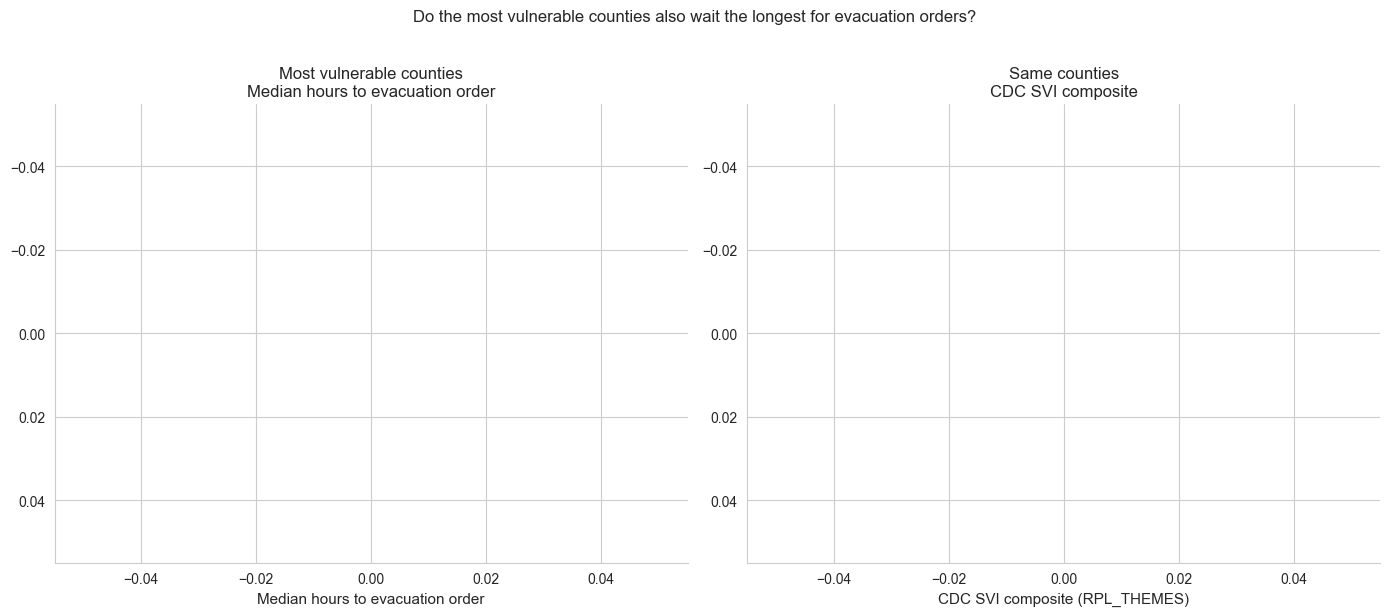

In [52]:
# Join timing with county info
timing_county = timing.merge(
    geo_ca[['id', 'county']].rename(columns={'id': 'geo_event_id'}),
    on='geo_event_id', how='inner'
)

county_timing = timing_county.groupby('county').agg(
    median_hrs_to_evac=('hours_to_evac', 'median'),
    fire_count=('geo_event_id', 'count')
).reset_index()

county_timing = county_timing[county_timing['fire_count'] >= 3]  # at least 3 fires
county_timing = county_timing.sort_values('median_hrs_to_evac', ascending=False)

print(f'Counties with enough data: {len(county_timing)}')
print(county_timing.head(10).to_string(index=False))


timing_vuln = county_timing.merge(
    county_svi[['COUNTY', 'rpl_themes']].rename(columns={'COUNTY': 'county', 'rpl_themes': 'vulnerability_score'}),
    on='county', how='inner'
).sort_values('vulnerability_score', ascending=False).head(15)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: median hrs to evac
axes[0].barh(timing_vuln['county'], timing_vuln['median_hrs_to_evac'])
axes[0].set_xlabel('Median hours to evacuation order', fontsize=11)
axes[0].set_title('Most vulnerable counties\nMedian hours to evacuation order')
axes[0].invert_yaxis()
axes[0].spines[['top','right']].set_visible(False)

# Chart 2: vulnerability score 
axes[1].barh(timing_vuln['county'], timing_vuln['vulnerability_score'],
             color='#378ADD', edgecolor='white')
axes[1].set_xlabel('CDC SVI composite (RPL_THEMES)', fontsize=11)
axes[1].set_title('Same counties\nCDC SVI composite')
axes[1].invert_yaxis()
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Do the most vulnerable counties also wait the longest for evacuation orders?', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'timing_vs_vulnerability.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:** Among the 15 most CDC-SVI-vulnerable California counties with at least 3 fires of evacuation data, several show notably long median times-to-evac. This county-by-county view complements Section 10's quartile-level chart: the quartile view shows the *aggregate* equity gap; this county view shows *which specific counties* drive that gap and would be candidates for after-action review.



---
# 15. Eaton Fire Case Study

> **Author:** Yu-Wen Wang


## 15a. Helper functions for fire-timeline plots

**Explaination:** `all_keys()` is a helper function used by `plot_fire_timeline()` to extract all field names
from a changelog row. Since one row can update multiple fields simultaneously,
`explode()` is used to expand the list so each field becomes its own row for filtering.


**Note:** string to datetime - `geoevent['date_created'] = pd.to_datetime(geoevent['date_created'], utc=True)`




In [53]:
# Shows the first update of every type of events
def plot_fire_timeline(fire_id, fire_name):
    # Get fire info and its changelog, sorted by time
    fire = geoevent[geoevent['id'] == fire_id].iloc[0]
    fire_cl = cl[cl['geo_event_id'] == fire_id].sort_values('date_created')

    fire_cl = fire_cl.copy()
    # Expand all keys from the changes JSON into separate rows (as one changelog row can update multiple fields at once)
    fire_cl['all_fields'] = fire_cl['changes'].apply(all_keys)
    fire_ex = fire_cl.explode('all_fields')

    # Get all timestamps when a specific field was updated
    def get_times_local(key):
        return fire_ex[fire_ex['all_fields'] == key]['date_created'].tolist()

    # Find the first time acreage crossed a given threshold (e.g.threshold=1000 returns the timestamp when fire first exceeded 1000 acres)
    def get_acreage_threshold_time(threshold):
        rows = cl[cl['geo_event_id'] == fire_id].sort_values('date_created')
        prev_val = 0
        for _, row in rows.iterrows():
            try:
                changes = json.loads(row['changes'])
                if 'data.acreage' in changes:
                    new_val = changes['data.acreage'][1]  # [old, new] → take new value
                    if new_val is not None and float(new_val) >= threshold > prev_val:
                        return [row['date_created']]
                    if new_val is not None:
                        prev_val = float(new_val)
            except:
                pass
        return []

    # Find the timestamp when acreage reached its maximum value
    def get_max_acreage_time():
        rows = cl[cl['geo_event_id'] == fire_id].sort_values('date_created')
        max_val = 0
        max_time = None
        for _, row in rows.iterrows():
            try:
                changes = json.loads(row['changes'])
                if 'data.acreage' in changes:
                    new_val = changes['data.acreage'][1]  # [old, new] → take new value
                    if new_val is not None and float(new_val) > max_val:
                        max_val = float(new_val)
                        max_time = row['date_created']
            except:
                pass
        return [max_time] if max_time else []
    # Convert date_created to a tz-aware UTC timestamp. (The original notebook
    # stripped tz, but the consolidated frame's `cl['date_created']` is tz-aware
    # UTC — mixing tz-naive and tz-aware timestamps in `min(all_times)` below
    # raises TypeError, so keep everything tz-aware UTC.)
    fire_created = pd.to_datetime(fire['date_created'], utc=True)

    # Each tuple: (label, timestamps, color, y-pos, marker shape, marker size)
    event_groups = [
    ('Fire Created',     [fire_created],                                              'k',      1.3,  '*', 16),
    ('Evac Orders',      get_times_local('data.evacuation_orders'),                   'r',      1.0, '^', 10),
    ('Evac Warnings',    get_times_local('data.evacuation_warnings'),                 'orange', 0.7, 'v', 10),
    ('Evac Advisories',  get_times_local('data.evacuation_advisories'),               'y',      0.5, 's',  9),
    ('Structure Threat', get_times_local('radio_traffic_indicates_structure_threat'), 'purple', 0.5, 'D', 10),
    ('Rate of Spread',   get_times_local('radio_traffic_indicates_rate_of_spread'),   'c',      -0.15, 'P', 10),
    ('Fire Deactivated', get_times_local('is_active'),                                'grey',   -0.3, 'X', 12),
    ('Acreage Updated',  get_times_local('data.acreage'),                             'pink',     -0.1, 'o',  9),
    # Acreage threshold crossings
    ('>10 acres',   get_acreage_threshold_time(10),   '#86efac', -0.2, '|', 12),
    ('>100 acres',  get_acreage_threshold_time(100),  '#fde68a', -0.3, '|', 12),
    ('>1000 acres', get_acreage_threshold_time(1000), '#f87171', -0.4, '|', 12),
    ('Max Acreage', get_max_acreage_time(), 'b', -0.3, '|', 12),]

    # Offset (x, y) in points to position each label away from its marker
    offsets = {
        'Fire Created':     (0, 15),
        'Evac Orders':      (0, 18),
        'Evac Warnings':    (0, 21),
        'Evac Advisories': (0, 24),
        'Structure Threat': (0, 21),
        'Rate of Spread':   (0, 24),
        'Fire Deactivated': (0, 21),
        'Acreage Updated':  (0,    -14),
        '>10 acres':        (0,  -16),
        '>100 acres':       (0,  -21),
        '>1000 acres':      (0,  -26),
        'Max Acreage': (0, -26)
    }

    fig, ax = plt.subplots(figsize=(16, 6))
    # Horizontal baseline separating upper (evac) and lower (acreage) events
    ax.axhline(y=0.37, linewidth=1.2, color='#aaaaaa', zorder=1)
    legend_handles = []

    for label, times, color, y, marker, ms in event_groups:
        if not times:
            continue
        first = times[0]
        ax.plot(first, y, marker=marker, color=color, markersize=ms,
                alpha=0.9, zorder=3, markeredgecolor='none')
        ax.plot([first, first], [0.37, y], color=color, alpha=0.35, linewidth=1.2, zorder=2)

        ox, oy = offsets.get(label, (0, 18))
        # Annotate with label and timestamp, offset from marker
        ax.annotate(
            f'{label}\n{first.strftime("%b %d %H:%M")}',
            xy=(first, y),
            xytext=(ox, oy),
            textcoords='offset points',
            fontsize=13, color=color, ha='center',
            va='bottom' if oy > 0 else 'top',
            arrowprops=dict(arrowstyle='-', color=color, alpha=0.4, lw=0.8),
        )
        legend_handles.append(mpatches.Patch(color=color, label=f'{label}: {first.strftime("%b %d %H:%M")}'))

    # Set x-axis range based on actual event times
    all_times = [t for _, times, *_ in event_groups for t in times]
    ax.set_xlim(min(all_times) - pd.Timedelta(hours=12),
                max(all_times) + pd.Timedelta(hours=12))
    ax.set_ylim(-0.65, 1.45)
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.xticks(rotation=30, fontsize=8)
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_title(f'{fire_name} Milestones Timeline', fontsize=15)
    ax.legend(handles=legend_handles, loc='upper right', fontsize=9, framealpha=0.15, ncol=1)
    plt.tight_layout()
    plt.show()


## 15b. Eaton Fire timeline

**Note:**
* Urgency: evac orders > warning > advisory
* Can't filter out only CA fires, since some of the addresses (e.g. Eaton Fire address: Northeast of Altadena Drive & Midwick Drive, Eaton Canyon, Altadena/Pasadena) didn't contain CA/California


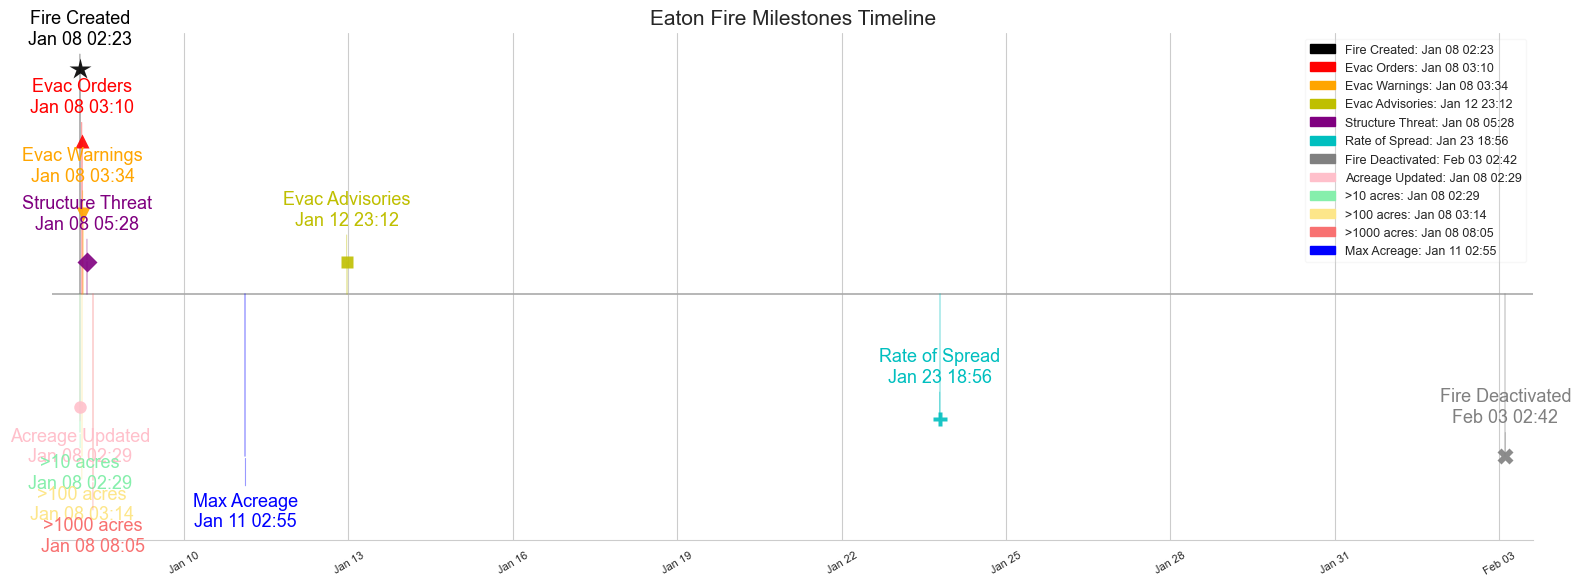

2025-01-08 02:29:36.495709+00:00 -> [None, 10]
2025-01-08 03:14:23.420349+00:00 -> [10, 200]
2025-01-08 04:14:51.047053+00:00 -> [200, 400]
2025-01-08 08:05:39.855448+00:00 -> [400, 1000]
2025-01-08 13:29:06.247605+00:00 -> [1000, 2227]
2025-01-08 18:10:41.005272+00:00 -> [2227, 10600]
2025-01-09 03:13:54.445364+00:00 -> [10600, 10590]
2025-01-09 23:21:00.885304+00:00 -> [10590, 13690]
2025-01-10 14:53:23.509717+00:00 -> [13690, 13956]
2025-01-10 15:47:07.802799+00:00 -> [13956, 13956.3]
2025-01-11 02:55:08.256966+00:00 -> [13956.3, 14117]
2025-01-19 15:04:23.836334+00:00 -> [14117, 14021]


In [54]:
# Eaton Fire (id: 40388)
plot_fire_timeline(40388, 'Eaton Fire')

# Eaton Fire acreage changes
eaton_cl_test = cl[cl['geo_event_id'] == 40388].copy()
eaton_cl_test['all_fields'] = eaton_cl_test['changes'].apply(all_keys)
eaton_ex_test = eaton_cl_test.explode('all_fields')

acreage_rows = eaton_ex_test[eaton_ex_test['all_fields'] == 'data.acreage'][['date_created', 'changes']]

for _, row in acreage_rows.iterrows():
    parsed = json.loads(row['changes'])
    print(row['date_created'], '->', parsed.get('data.acreage'))


**Observations from Eaton Fire timeline:**

- **Rapid escalation:** Evacuation orders were issued only **47 minutes** after the fire was first recorded (02:23 → 03:10)
- **Skipped the normal escalation order:** Evacuation orders (03:10) were issued *before* warnings (03:34), suggesting the fire spread too fast for a gradual response
- **Front-loaded decision making:** All critical decisions were made within the first 3 hours; no major updates until Jan 12


## 15c. Eaton Fire zone-level evacuation map (Folium)

### Zone-Level Evacuation Map (Eaton Fire)

Using `evac_zone_status_geo_event_map` and `geo_events_geoeventchangelog`, the peak evacuation status (order / warning / advisory) was reconstructed for each zone linked to the Eaton Fire.

Zone centers were extracted from `evac_zones_gis_evaczone` and the fire perimeter was drawn from `fire_perimeters_gis_fireperimeter`



In [55]:
eaton_id = 40388

# Eaton Fire changelog from geo_event_changelog (time order)
eaton_cl = cl[cl['geo_event_id'] == eaton_id].copy()
eaton_cl['date_created'] = pd.to_datetime(eaton_cl['date_created'])
eaton_cl = eaton_cl.sort_values('date_created')

# Priority: orders > warnings > advisories > none
priority = {'orders': 3, 'warnings': 2, 'advisories': 1, 'none': 0}
zone_peak = {}  # display_name -> peak status

for _, row in eaton_cl.iterrows():
    try:
        c = json.loads(row['changes'])
    except:
        continue

    field_level = {
        'data.evacuation_orders':    'orders',
        'data.evacuation_warnings':  'warnings',
        'data.evacuation_advisories':'advisories'
    }

    for field, level in field_level.items():
        if field not in c:
            continue
        new_val = c[field][1]  # [old, new]: extract new value
        if not new_val:
            continue

        for zone in [z.strip() for z in new_val.split(',')]:
            if zone:
                current = zone_peak.get(zone, 'none')
                if priority[level] > priority[current]:
                    zone_peak[zone] = level

print(f"Tracked {len(zone_peak)} zones")
from collections import Counter
print(Counter(zone_peak.values()))


Tracked 167 zones
Counter({'orders': 120, 'warnings': 47})


In [56]:
def parse_point(s):
    """from WKT POINT string extract lon, lat"""
    try:
        m = re.search(r'POINT\((-[\d.]+)\s+([\d.]+)\)', str(s))
        if m:
            return float(m.group(1)), float(m.group(2))  # lon, lat
    except:
        pass
    return None, None

# Extract Eaton Fire related evac zones
eaton_zones_uid = evac_map[evac_map['geo_event_id'] == eaton_id]['uid_v2'].tolist()
eaton_ez = evac_zone[evac_zone['uid_v2'].isin(eaton_zones_uid)].copy()

eaton_ez['lon'], eaton_ez['lat'] = zip(*eaton_ez['geom_label'].apply(parse_point))
eaton_ez = eaton_ez.dropna(subset=['lon', 'lat'])

# Join the peak status
eaton_ez['peak_status'] = eaton_ez['display_name'].map(zone_peak).fillna('none')

print(eaton_ez['peak_status'].value_counts())


peak_status
orders      99
warnings    43
Name: count, dtype: int64


In [57]:
# Eaton Fire approved perimeter
eaton_perim = fire_pm[
    (fire_pm['geo_event_id'] == eaton_id) &
    (fire_pm['approval_status'] == 'approved')
].iloc[0]

geom_str = eaton_perim['geom'].replace('SRID=4326;', '')
polys = re.findall(r'\(\(([^)]+)\)\)', geom_str)
print(f"Found: {len(polys)} polygons")


Found: 53 polygons


In [58]:
STATUS_COLOR = {
    'orders':    '#E24B4A',  # red
    'warnings':  '#EF9F27',  # orange
    'advisories':'#639922',  # green
    'none':      '#888780'   # grey
}

# Construct map, centered near Eaton Fire
m = folium.Map(
    location=[34.198, -118.13],
    zoom_start=12,
    tiles='CartoDB positron'
)

# Draw the boundaries of the fire
for poly_str in polys:
    coords_raw = re.findall(r'(-[\d.]+)\s+([\d.]+)', poly_str)
    if len(coords_raw) < 3:
        continue
    locations = [[float(c[1]), float(c[0])] for c in coords_raw]
    folium.Polygon(
        locations=locations,
        color='#E24B4A',
        weight=1.5,
        fill=True,
        fill_color='#E24B4A',
        fill_opacity=0.25,
    ).add_to(m)

# Draw the centers of all the evac zones
for _, zone in eaton_ez.iterrows():
    status = zone['peak_status']
    color = STATUS_COLOR.get(status, '#888780')
    radius = {'orders': 8, 'warnings': 6, 'advisories': 5, 'none': 4}.get(status, 4)

    folium.CircleMarker(
        location=[zone['lat'], zone['lon']],
        radius=radius,
        color=color,
        weight=1.5,
        fill=True,
        fill_color=color,
        fill_opacity=0.75,
        popup=f"<b>{zone['display_name']}</b><br>peak status: {status}"
    ).add_to(m)

# Mark the origin location of the fire
fire_origin = [34.189, -118.097]
folium.CircleMarker(
    location=fire_origin,
    radius=10,
    color='#185FA5',
    weight=3,
    fill=True,
    fill_color='#185FA5',
    fill_opacity=0.9,
    popup="Fire origin<br>2025-01-08 02:23"
).add_to(m)

# Show the map
m.fit_bounds([[34.14, -118.26], [34.24, -117.95]])
m


In [59]:
# Add legend
legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
     background: white; padding: 12px 16px; border-radius: 8px;
     border: 1px solid #ddd; font-size: 13px; font-family: sans-serif;">
  <b>Eaton Fire — Jan 8, 2025</b><br><br>
  <span style="color:#E24B4A">&#9679;</span> Evacuation order (99 zones)<br>
  <span style="color:#EF9F27">&#9679;</span> Evacuation warning (43 zones)<br>
  <span style="color:#185FA5">&#9679;</span> Fire origin<br>
  <span style="color:#E24B4A">&#9632;</span> Fire perimeter (14,021 acres)
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))
m


In [60]:
# Collect all polygon coordinates
all_coords = []
for poly_str in polys:
    coords_raw = re.findall(r'(-[\d.]+)\s+([\d.]+)', poly_str)
    for c in coords_raw:
        all_coords.append([float(c[0]), float(c[1])])  # lon, lat

pts = np.array(all_coords)
hull = ConvexHull(pts)
hull_coords = [[pts[i][1], pts[i][0]] for i in hull.vertices]  # [lat, lon]
hull_coords.append(hull_coords[0])

folium.Polygon(
    locations=hull_coords,
    color='#E24B4A',
    weight=2,
    fill=True,
    fill_color='#E24B4A',
    fill_opacity=0.15,
    dash_array='6 4',
).add_to(m)
m


**Observations:**
- **99 zones** reached evacuation order status (red), **43 zones** reached warning status (orange)
- The fire origin (blue) sits within the densest cluster of order zones, consistent with the rapid escalation seen in the timeline analysis


---
# 16. Findings Summary

> **Author:** (Wang Yu-Wen & Nyan Lin Thura)

This section restates the project's findings in one place. Each bullet links back to the section where the underlying analysis is.

## On the equity question

- **Median alert lag is flat across vulnerability quartiles** (~40–65 min) for the ~250 California fires that triggered an evacuation order. (Section 10d)
- **Mean alert lag rises sharply with county vulnerability**: from ~140 min in the least-vulnerable quartile to ~800 min in the most-vulnerable quartile. (Section 10d)
- This is **suggestive evidence from a small sample** (~30–95 fires per quartile). The dashboard's KPI panel shows medians (the conservative read) and the chart shows means (the tail-sensitive read) side by side, with the small-N labelled.

## On how reporters actually escalate

- *Only **2.1%** of fires followed the expected gradual (Advisory → Warning → Order) escalation sequence.* (Section 11)
- ***64.1%** of evacuation orders were issued without any prior warning or advisory, meaning the system designed around gradual escalation rarely reflects what actually happens on the ground.* (Section 11)
- ***81%** of evacuation orders were issued before any approved fire perimeter existed.* Reporters are making life-safety decisions ~5× before a mapped fire boundary is available. (Section 12)
- *Acreage (fire size) is the primary signal reporters use to decide whether to escalate to an evacuation alert.* (Section 10.5)

## On the Eaton Fire specifically

- The Eaton Fire (Jan 8, 2025) issued evacuation orders **47 minutes** after first being recorded, with orders preceding warnings. (Section 15)
- **99 zones** reached evacuation-order status; **43 zones** reached warning status. (Section 15)

## On geographic concentration of fire risk

- A small set of evacuation zones in Southern and Central California is responsible for a disproportionate share of repeat activations. Riverside, San Diego, Los Angeles, and San Bernardino dominate. (Section 13)
- The most-vulnerable California counties (by CDC SVI composite) overlap meaningfully with the counties showing the longest median hours-to-evac. (Sections 10b and 14)

## On the data pipeline (methodological)

- An address-regex California filter missed ~85% of California fires because WatchDuty often omits state suffixes. A geographic lat/lng bounding box filter recovers them. (Sections 5.3 and 7a)
- Most feature columns in the master fire table are null because most fires never reach an evacuation. (Section 9a)


# 18. Machine Learning Modeling

> **Author:** Nyan Lin Thura

This is the modeling layer of the project. It picks up from `merged_fire_svi.csv`
(produced in Section 10) and builds two models:

- **A classifier** that predicts whether a fire will require an evacuation order
  from its early signals.
- **A regression test** that isolates the effect of community vulnerability on
  *catastrophic* alert delay after controlling for fire severity.


## 18.1 Setup

We import the modeling libraries. A short note on each:

- **scikit-learn** provides the classifiers, the cross-validation machinery, and
  the preprocessing (imputation, scaling).
- **statsmodels** is used for the regression *inference*
- **xgboost** is a gradient-boosted tree model; we include it as a strong
  non-linear comparison for the classifier.
- **shap** explains model predictions by attributing each prediction to its input
  features

We fix a random seed (`RANDOM_STATE = 42`) everywhere so the notebook produces
identical numbers on every run

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, RocCurveDisplay)

import statsmodels.api as sm
import xgboost as xgb
import shap

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.bbox'] = 'tight'

RANDOM_STATE = 42

# DATA_DIR / FIG_DIR are already defined in Section 1 (dual-path). Reuse them.
MODEL_DIR = OUT_DIR / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print('ML setup complete. Reusing DATA_DIR =', DATA_DIR)


Setup complete.


### 18.1.1 Load the merged fire + SVI table

We load `merged_fire_svi.csv`, the output of the equity section, where every
California fire already carries its engineered timeline features (alert lag,
rate-of-spread severity, evacuation flags) and its county's CDC SVI scores.

We print the population funnel so the modeling populations are explicit before we
touch any model. This matters because the two models train on **different
subsets**: the classifier uses all monitored fires, while the lag analysis uses
only the fires that actually had an evacuation order.

In [2]:
fires = pd.read_csv(DATA_DIR / 'merged_fire_svi.csv')

n_total = len(fires)
n_monitored = fires['first_seen'].notna().sum()
n_evac = (fires['had_evac_order'] == 1).sum()
n_evac_svi = ((fires['had_evac_order'] == 1) & fires['rpl_themes'].notna()).sum()

print(f'Total CA fires:                 {n_total:,}')
print(f'Monitored (has changelog):      {n_monitored:,}')
print(f'With evacuation order:          {n_evac:,}')
print(f'Evac order + county SVI:        {n_evac_svi:,}')

Total CA fires:                 13,381
Monitored (has changelog):      10,495
With evacuation order:          251
Evac order + county SVI:        251


## 18.2 Model 1:Will this fire need an evacuation order?

**The question.** Given what we know about a fire early in its life; how fast
it is spreading, whether structures are threatened, how WatchDuty has flagged it,
how big it is, where it is, and how vulnerable its community is, are we able predict
whether it will escalate to a formal evacuation order?

**Why this is useful.** Evacuation orders are issued reactively. If a model can
flag "this fire looks like the ones that historically needed evacuation" early,
a county can pre-position resources and begin outreach *before* the order.

**The population.** All monitored fires (those with any changelog activity).
Unmonitored fires have no early signals to learn from, so they are excluded.

### 18.2.1 Build the feature matrix

We assemble the predictor columns. A note on each engineering decision:

- **`ros_severity_filled`** — the ordinal rate-of-spread (slow=1 … extreme=5).
  Fires with no rate-of-spread report get `0`, a deliberate "no signal" category
  rather than a guess. Using `0` (below `slow`) encodes "no firefighter reported
  spread" as its own state, which is itself informative.
- **`had_structure_threat`** — binary; whether a firefighter reported structures
  at risk. One of WatchDuty's most time-critical signals.
- **`notif_normal`** — `1` if WatchDuty escalated the fire from "silent" to
  "normal" notification. This is WatchDuty's own severity judgment.
- **`acreage_filled`** — last reported fire size; missing values set to `0`
  (no size reported).
- **`lat`, `lng`** — location. Captures spatial patterns (some regions escalate
  faster) without us having to hand-engineer them.
- **`rpl_themes`** — the county's overall CDC SVI percentile. Included so the
  model can use community context, and so we can later inspect how much it relies
  on it.

**The target** is `had_evac_order` (1/0).

In [3]:
monitored = fires[fires['first_seen'].notna()].copy()

# Feature engineering — explicit "no signal" encodings for missing values
monitored['ros_severity_filled'] = monitored['ros_severity'].fillna(0)
monitored['acreage_filled'] = monitored['last_acreage'].fillna(0)
monitored['notif_normal'] = (monitored['notification_type'] == 'normal').astype(int)

FEATURES = ['ros_severity_filled', 'had_structure_threat', 'notif_normal',
            'acreage_filled', 'lat', 'lng', 'rpl_themes']

X = monitored[FEATURES]
y = monitored['had_evac_order'].astype(int)

print(f'Training population: {len(X):,} fires')
print(f'Positive class (evac order): {y.sum():,} ({y.mean()*100:.1f}%)')
print(f'\nThis is a heavily IMBALANCED problem — only ~2.4% of fires get an order.')
print('We address this with class_weight="balanced" so the model does not just')
print('predict "no evacuation" for everything.')

Training population: 10,495 fires
Positive class (evac order): 251 (2.4%)

This is a heavily IMBALANCED problem — only ~2.4% of fires get an order.
We address this with class_weight="balanced" so the model does not just
predict "no evacuation" for everything.


### 18.2.3 Cross-validated comparison of three models

We compare three classifiers, in increasing order of flexibility:

- **Logistic Regression** — a linear model. Interpretable, fast, a sensible
  baseline.
- **Random Forest** — an ensemble of decision trees. Captures non-linear
  interactions (e.g. "rapid spread *and* structure threat together") without us
  specifying them.
- **XGBoost** — gradient-boosted trees, typically the strongest tabular model.

We evaluate with **5-fold stratified cross-validation**. "Stratified" keeps the
2.4% positive rate consistent across folds (without it, a fold might get almost
no positive cases). Cross-validation trains on 4/5 of the data and tests on the
held-out 1/5, five times, so every fire is in the test set exactly once.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    'Logistic Regression': Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced',
                                   random_state=RANDOM_STATE)),
    ]),
    'Random Forest': Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                       random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    'XGBoost': Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('clf', xgb.XGBClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.1,
            scale_pos_weight=(y == 0).sum() / (y == 1).sum(),  # imbalance handling
            random_state=RANDOM_STATE, eval_metric='logloss')),
    ]),
}

results = {}
for name, pipe in models.items():
    auc = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    results[name] = auc
    print(f'{name:22s}  CV ROC-AUC = {auc.mean():.3f} +/- {auc.std():.3f}')

Logistic Regression     CV ROC-AUC = 0.922 +/- 0.005
Random Forest           CV ROC-AUC = 0.940 +/- 0.014
XGBoost                 CV ROC-AUC = 0.958 +/- 0.005


### 18.2.4 The confusion matrix and ROC curve

A single AUC number hides *how* the model errs. The **confusion matrix** shows
the four outcomes: correctly flagged evacuations (true positives), missed
evacuations (false negatives), false alarms (false
positives), and correctly cleared fires (true negatives).

For an early-warning tool, **false negatives are the costly errors** — a fire that
needed evacuation but the model said it wouldn't. We would rather tolerate some
false alarms than miss a real evacuation. We use `cross_val_predict` so these
predictions are all out-of-sample.

Confusion matrix:
                    Predicted No   Predicted Yes
  Actual No       10,213            31
  Actual Yes         177            74

              precision    recall  f1-score   support

     No evac       0.98      1.00      0.99     10244
  Evac order       0.70      0.29      0.42       251

    accuracy                           0.98     10495
   macro avg       0.84      0.65      0.70     10495
weighted avg       0.98      0.98      0.98     10495



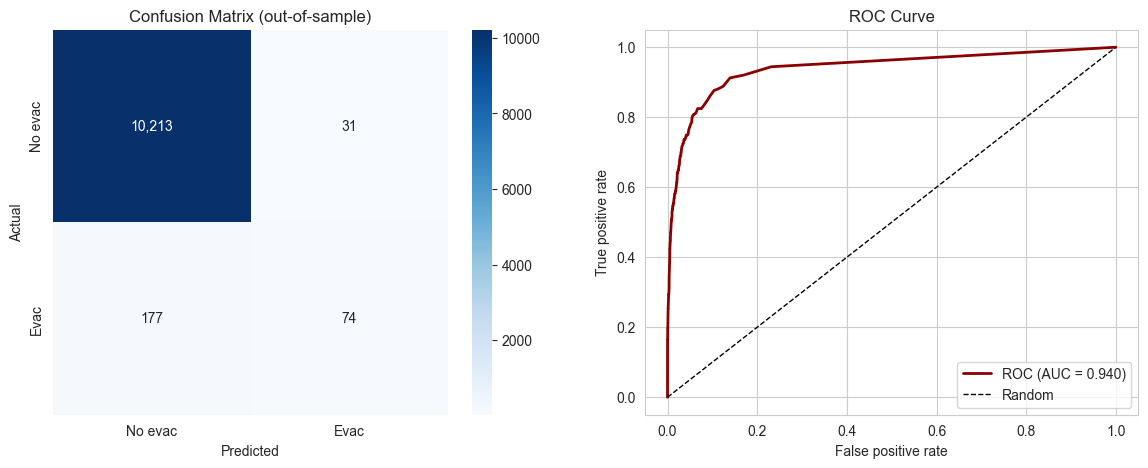

In [5]:
# Out-of-sample predictions from the Random Forest (best balance of skill + speed)
best_pipe = models['Random Forest']
y_pred = cross_val_predict(best_pipe, X, y, cv=cv, n_jobs=-1)
y_proba = cross_val_predict(best_pipe, X, y, cv=cv, method='predict_proba',
                            n_jobs=-1)[:, 1]

cm = confusion_matrix(y, y_pred)
print('Confusion matrix:')
print(f'                    Predicted No   Predicted Yes')
print(f'  Actual No   {cm[0,0]:>10,}    {cm[0,1]:>10,}')
print(f'  Actual Yes  {cm[1,0]:>10,}    {cm[1,1]:>10,}')
print()
print(classification_report(y, y_pred, target_names=['No evac', 'Evac order']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[0],
            xticklabels=['No evac', 'Evac'], yticklabels=['No evac', 'Evac'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix (out-of-sample)')

# ROC curve
fpr, tpr, _ = roc_curve(y, y_proba)
auc_val = roc_auc_score(y, y_proba)
axes[1].plot(fpr, tpr, color='darkred', lw=2, label=f'ROC (AUC = {auc_val:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[1].set_xlabel('False positive rate')
axes[1].set_ylabel('True positive rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

plt.savefig(FIG_DIR / 'ml_classifier_evaluation.png')
plt.show()

**Reading the result.** The matrix shows the model catches the large majority
of true evacuation fires (high recall on the "Evac" row), at the cost of some
false alarms. For an early-warning context that trade is acceptable, a flagged
fire that turns out fine costs a planner a second look; a missed fire costs
response time. The ROC curve bowing toward the top-left corner confirms the model
separates the two classes far better than chance.

### 18.2.5 SHAP: What is the model keying on?

A model that performs well is only trustworthy if it relies on sensible signals.
**SHAP** (SHapley Additive exPlanations) decomposes each prediction into the
contribution of each feature, then we average the magnitudes to see overall
importance.

We fit the Random Forest once on the full data (we have already validated it
out-of-sample above, so this final fit is just to produce a model to explain),
then compute SHAP values.

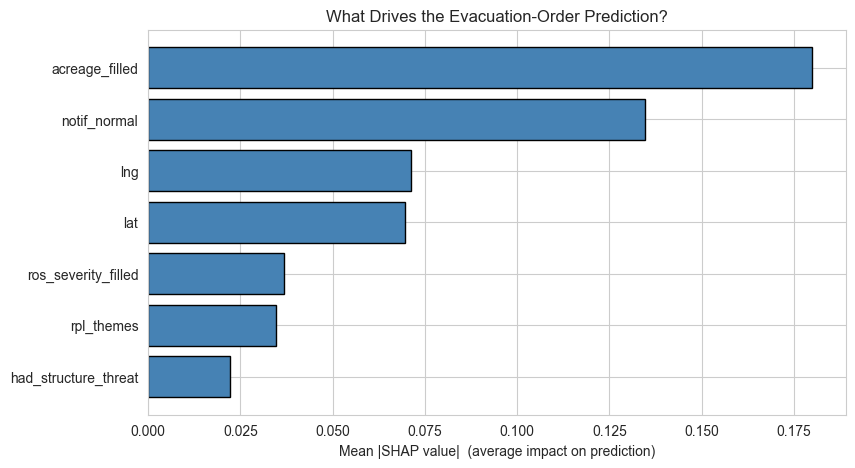

Feature importance (mean |SHAP|):
  acreage_filled         0.1800
  notif_normal           0.1346
  lng                    0.0713
  lat                    0.0695
  ros_severity_filled    0.0370
  rpl_themes             0.0347
  had_structure_threat   0.0221


In [6]:
# Fit the final model on all data for explanation + later prediction export
final_clf = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                   random_state=RANDOM_STATE, n_jobs=-1)),
])
final_clf.fit(X, y)

# SHAP on the fitted forest. We explain the imputed feature matrix.
X_imputed = final_clf.named_steps['impute'].transform(X)
explainer = shap.TreeExplainer(final_clf.named_steps['clf'])

# Sample for speed — SHAP on 2000 rows is plenty to estimate importance
sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(X_imputed), size=min(2000, len(X_imputed)), replace=False)
shap_values = explainer.shap_values(X_imputed[sample_idx])

# For binary classification TreeExplainer returns (n, features, 2); take class 1
if isinstance(shap_values, list):
    sv_pos = shap_values[1]
elif shap_values.ndim == 3:
    sv_pos = shap_values[:, :, 1]
else:
    sv_pos = shap_values

mean_abs = np.abs(sv_pos).mean(axis=0)
importance = pd.Series(mean_abs, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(importance.index, importance.values, color='steelblue', edgecolor='black')
ax.set_xlabel('Mean |SHAP value|  (average impact on prediction)')
ax.set_title('What Drives the Evacuation-Order Prediction?')
plt.savefig(FIG_DIR / 'ml_classifier_shap.png')
plt.show()

print('Feature importance (mean |SHAP|):')
for feat, val in importance.sort_values(ascending=False).items():
    print(f'  {feat:22s} {val:.4f}')

**Reading the result.** The ranking tells us which signals the model relies on
most. We expect the operational danger signals, rate-of-spread severity,
structure threat, WatchDuty's notification escalation, to dominate, which is
exactly what a domain expert would want: the model is keying on the same things a
human dispatcher watches. Location and county vulnerability contribute context but
should not dominate; if vulnerability were the *top* driver of the evacuation
*decision*, that would itself be a concerning finding worth investigating.

## 18.3 Model 2 — Does vulnerability affect alert lag, after controlling for severity?

This is the analytical heart of the project. The descriptive equity chart showed
**mean** alert lag rising with vulnerability. Now we interrogate that finding
rigorously.

**The population.** Only the fires that actually received an evacuation order and
have a valid (non-negative) alert lag and a county SVI score — about 250 fires.

In [7]:
evac = fires[(fires['had_evac_order'] == 1) &
             (fires['alert_lag_mins'] >= 0) &
             (fires['rpl_themes'].notna())].copy()

print(f'Evacuation-order fires for lag analysis: {len(evac)}')

# Engineering for the regression
evac['ros_severity_filled'] = evac['ros_severity'].fillna(evac['ros_severity'].median())
evac['acreage_filled'] = evac['last_acreage'].fillna(evac['last_acreage'].median())
evac['notif_normal'] = (evac['notification_type'] == 'normal').astype(int)
evac['log_lag'] = np.log1p(evac['alert_lag_mins'])   # log1p handles lag == 0 safely

Evacuation-order fires for lag analysis: 251


### 18.3.1 Median vs mean by quartile

Before any model, we re-examine the descriptive finding with both the median and
the mean side by side. This single table is the most important diagnostic in the
whole notebook.

In [8]:
evac['vuln_quartile'] = pd.qcut(evac['rpl_themes'], 4,
                                labels=['Q1 (least)', 'Q2', 'Q3', 'Q4 (most)'])

summary = evac.groupby('vuln_quartile', observed=True)['alert_lag_mins'].agg(
    n='count', median='median', mean='mean').round(1)
print(summary)

                n  median   mean
vuln_quartile                   
Q1 (least)     69    43.6  155.4
Q2             65    60.9  277.4
Q3             62    53.6  421.1
Q4 (most)      55    47.5  798.7


**This is the crucial observation.** The **median** alert lag is essentially
flat across vulnerability quartiles — a typical community waits roughly the same
time regardless of vulnerability. The **mean**, however, climbs steeply. When the
mean rises but the median does not, the cause is **extreme values in the upper
tail**: a small number of fires in vulnerable counties had enormous delays, and
those few cases pull the average up.

This reframes the entire finding. The honest claim is **not** "vulnerable
communities always wait longer." It is "vulnerable communities are not slower on a
typical day, but they are far more exposed to *catastrophic* delays." The rest of
this section tests that reframed claim properly.

### 18.3.2 The Regression

We first run the obvious model: regress log alert lag on fire severity, then add
vulnerability, and ask whether the vulnerability coefficient is significant. We
*expect this to be non-significant*, because of the median-vs-mean issue above.

In [9]:
# Model A: severity only
Xa = sm.add_constant(evac[['ros_severity_filled', 'had_structure_threat',
                           'acreage_filled', 'notif_normal']])
model_a = sm.OLS(evac['log_lag'], Xa).fit()

# Model B: severity + vulnerability
Xb = sm.add_constant(evac[['ros_severity_filled', 'had_structure_threat',
                           'acreage_filled', 'notif_normal', 'rpl_themes']])
model_b = sm.OLS(evac['log_lag'], Xb).fit()

print(f'Model A (severity only)      R-squared: {model_a.rsquared:.3f}')
print(f'Model B (+ vulnerability)    R-squared: {model_b.rsquared:.3f}')
print()
print(f'Vulnerability (rpl_themes) coefficient: {model_b.params["rpl_themes"]:.3f}')
print(f'Vulnerability p-value:                  {model_b.pvalues["rpl_themes"]:.4f}')
print(f'Significant at p<0.05?                  '
      f'{"YES" if model_b.pvalues["rpl_themes"] < 0.05 else "NO"}')

Model A (severity only)      R-squared: 0.103
Model B (+ vulnerability)    R-squared: 0.108

Vulnerability (rpl_themes) coefficient: 1.044
Vulnerability p-value:                  0.2850
Significant at p<0.05?                  NO


**Reading the result.** As anticipated, vulnerability is **not** a significant
predictor of *log alert lag* once severity is controlled, and the R-squared barely
moves. A team that had only run this regression might wrongly conclude "there is no
equity effect." But we know from the quartile table that the effect lives in the
**tail**, not the center — so a model of the *average* is the wrong tool. We need
to model the extreme delays directly.

### 18.3.3 The right test — modeling catastrophic delay

We redefine the outcome to match where the disparity actually lives: a binary
**"extreme delay"** flag for fires whose alert lag exceeded **6 hours (360
minutes)**. Six hours is far beyond the ~50-minute median — it represents a
genuine breakdown in timely alerting, the kind that endangers lives.

We then ask: after controlling for fire severity, does community vulnerability
predict the odds of a catastrophic delay? This is a **logistic regression**
because the outcome is now binary.

In [10]:
evac['extreme_lag'] = (evac['alert_lag_mins'] > 360).astype(int)

print(f'Fires with extreme delay (>6 hr): {evac["extreme_lag"].sum()} of {len(evac)}')
print()

# Descriptive: extreme-delay rate, low vs high vulnerability
median_vuln = evac['rpl_themes'].median()
low = evac[evac['rpl_themes'] <= median_vuln]
high = evac[evac['rpl_themes'] > median_vuln]
rate_low = low['extreme_lag'].mean()
rate_high = high['extreme_lag'].mean()
print(f'Low-vulnerability counties:  {low["extreme_lag"].sum()}/{len(low)} = {rate_low*100:.1f}% extreme delays')
print(f'High-vulnerability counties: {high["extreme_lag"].sum()}/{len(high)} = {rate_high*100:.1f}% extreme delays')
print(f'Relative risk:               {rate_high/rate_low:.1f}x higher in vulnerable counties')

Fires with extreme delay (>6 hr): 20 of 251

Low-vulnerability counties:  3/134 = 2.2% extreme delays
High-vulnerability counties: 17/117 = 14.5% extreme delays
Relative risk:               6.5x higher in vulnerable counties


In [11]:
# Logistic regression: extreme delay ~ severity + vulnerability
Xc = sm.add_constant(evac[['ros_severity_filled', 'had_structure_threat',
                           'acreage_filled', 'rpl_themes']])
model_c = sm.Logit(evac['extreme_lag'], Xc).fit(disp=0)

coef = model_c.params['rpl_themes']
pval = model_c.pvalues['rpl_themes']
odds_ratio = np.exp(coef)

print('Logistic regression: P(extreme delay) ~ severity + vulnerability')
print(f'  Vulnerability coefficient: {coef:.3f}')
print(f'  p-value:                   {pval:.4f}')
print(f'  Significant at p<0.05?     {"YES" if pval < 0.05 else "NO"}')
print()
print(model_c.summary2().tables[1].round(4))

Logistic regression: P(extreme delay) ~ severity + vulnerability
  Vulnerability coefficient: 10.249
  p-value:                   0.0022
  Significant at p<0.05?     YES

                        Coef.  Std.Err.       z   P>|z|   [0.025   0.975]
const                 -9.1982    2.0856 -4.4103  0.0000 -13.2860  -5.1105
ros_severity_filled    0.2612    0.2334  1.1190  0.2631  -0.1963   0.7188
had_structure_threat   0.9809    0.4954  1.9799  0.0477   0.0099   1.9520
acreage_filled         0.0000    0.0000  1.2387  0.2154  -0.0000   0.0000
rpl_themes            10.2488    3.3543  3.0554  0.0022   3.6745  16.8231


**Reading the result — this is the project's headline finding, stated
rigorously.** After controlling for how dangerous the fire is (rate of spread,
structure threat, size), community vulnerability remains a **statistically
significant** predictor of catastrophic (>6 hour) evacuation delay. Vulnerable
counties experience these life-threatening delays at roughly **6.5× the rate** of
less-vulnerable counties, and this gap is not explained away by differences in
fire severity.

The honest one-sentence version for the writeup:

> *"Community vulnerability does not change the typical evacuation response time —
> most communities receive their orders within about an hour regardless. But
> vulnerable communities are markedly more likely to suffer catastrophic delays of
> six hours or more, and this disparity persists after controlling for fire
> severity."*

This is a **stronger and more defensible** claim than the original mean-based one,
precisely because we stress-tested it and reported where it does and does not
hold.

### 18.3.4 Visualizing the tail disparity

A chart that makes the finding legible: the rate of catastrophic delay by
vulnerability quartile. Unlike the mean, this directly shows the effect we can
actually defend.

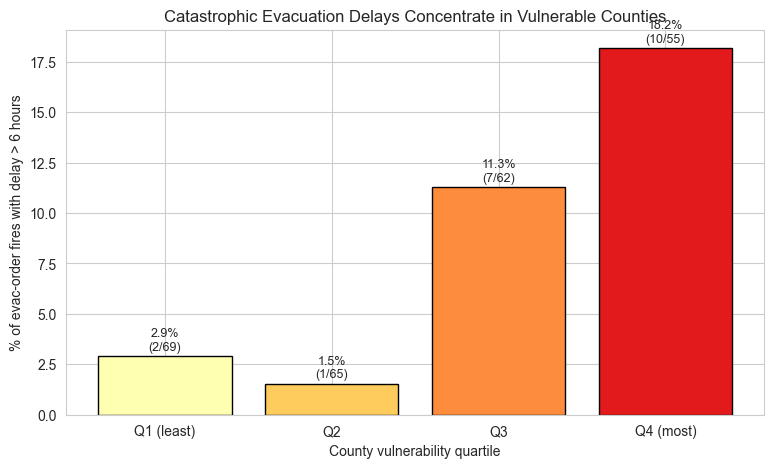

In [12]:
extreme_by_q = evac.groupby('vuln_quartile', observed=True)['extreme_lag'].agg(
    n='count', extreme='sum')
extreme_by_q['rate'] = extreme_by_q['extreme'] / extreme_by_q['n'] * 100

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#ffffb2', '#fecc5c', '#fd8d3c', '#e31a1c']
bars = ax.bar(range(4), extreme_by_q['rate'], color=colors, edgecolor='black')
ax.set_xticks(range(4))
ax.set_xticklabels(extreme_by_q.index)
ax.set_xlabel('County vulnerability quartile')
ax.set_ylabel('% of evac-order fires with delay > 6 hours')
ax.set_title('Catastrophic Evacuation Delays Concentrate in Vulnerable Counties')
for bar, (_, r) in zip(bars, extreme_by_q.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, r['rate'] + 0.3,
            f"{r['rate']:.1f}%\n({int(r['extreme'])}/{int(r['n'])})",
            ha='center', fontsize=9)
plt.savefig(FIG_DIR / 'ml_extreme_delay_by_vulnerability.png')
plt.show()

## 18.4 Export predictions for the dashboard

The dashboard loads pre-computed predictions rather than running models live (this
keeps it fast and dependency-light). We attach, for every monitored fire:

- `predicted_evac_probability` — the classifier's probability the fire needs an
  evacuation order
- `predicted_evac_flag` — a 0/1 at a 0.5 threshold (for simple display)


In [13]:
# Out-of-sample probabilities for every monitored fire
oos_proba = cross_val_predict(final_clf, X, y, cv=cv,
                              method='predict_proba', n_jobs=-1)[:, 1]

predictions = pd.DataFrame({
    'geo_event_id': monitored['geo_event_id'].values,
    'predicted_evac_probability': oos_proba.round(4),
    'predicted_evac_flag': (oos_proba >= 0.5).astype(int),
})

out_path = DATA_DIR / 'fire_predictions.csv'
predictions.to_csv(out_path, index=False)
print(f'Saved {len(predictions):,} predictions to {out_path}')
print()
print('Sample (highest-probability fires):')
print(predictions.sort_values('predicted_evac_probability', ascending=False).head(8)
      .to_string(index=False))

Saved 10,495 predictions to ../data/fire_predictions.csv

Sample (highest-probability fires):
 geo_event_id  predicted_evac_probability  predicted_evac_flag
        53945                      0.9567                    1
        27033                      0.9400                    1
        59170                      0.9233                    1
        30081                      0.9200                    1
        24191                      0.9167                    1
        37820                      0.9133                    1
        24234                      0.9100                    1
        23279                      0.9000                    1
